# Step 12: Link AequilibraE and UrbanSim — The LUTI Feedback Loop

**Kandy District LUTI Model — Dynamic Land-Use / Transport Simulation**

This notebook is the operational heart of the LUTI model. It couples the calibrated
AequilibraE transport model (Steps 9–10) with a UrbanSim-style land use model
(Step 11) through a Python orchestration layer, running a 20-year dynamic feedback
loop for all four scenarios.

---

## What this notebook does

| Sub-step | Module | Purpose |
|---|---|---|
| **12.1** | Accessibility Calculator | Hansen cumulative-opportunity index from AequilibraE skims |
| **12.2** | Data Transformation Layer | AequilibraE ↔ UrbanSim format converters + gravity OD |
| **12.3** | Land Use Models | Hedonic · Transition · HLCM · ELCM · Developer |
| **12.4** | Scenario Config | Travel-time modifiers for all 4 scenarios |
| **12.5** | LUTI Feedback Loop | Orchestration: 4 scenarios × 5 time steps (2026–2046) |
| **12.6** | Output Metrics | Shannon entropy · Affordability ratio · V/C proxy |
| **12.7** | Comparative Charts | 6 publication-quality figures |

## Prerequisites
- ✅ **Step 9** — AequilibraE project built; skims & OD matrix saved
- ✅ **Step 10** — Model calibrated (GEH ≥ 85 %); calibrated beta saved
- ✅ **Step 11** — UrbanSim tables assembled (zones, buildings, households, jobs)

## Scenarios
| ID | Name | Description |
|---|---|---|
| `baseline` | Do-Nothing | No new infrastructure; historical trend growth only |
| `scenario_a` | Highway Bypass | Kohuwala–Gatambe flyover; 18 % travel-time reduction |
| `scenario_b` | Bus Rapid Transit | BRT corridors; improved PT accessibility to station zones |
| `scenario_c` | TOD | BRT + upzoning near stations; higher-density mixed use |

**Time steps:** `2026 → 2031 → 2036 → 2041 → 2046` (four 5-year periods)


In [1]:
# ══════════════════════════════════════════════════════════════
# CELL 1 — Imports and environment check
# ══════════════════════════════════════════════════════════════
import os, json, warnings
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
np.random.seed(42)   # reproducible Monte Carlo location-choice draws

# ── Optional: UrbanSim / orca ──────────────────────────────────────────────
try:
    import orca
    from urbansim.models import RegressionModel, MNLLocationChoiceModel
    URBANSIM_AVAILABLE = True
    print('✓ UrbanSim / orca available')
except ImportError:
    URBANSIM_AVAILABLE = False
    print('ℹ  UrbanSim/orca not installed — built-in MNL will be used')
    print('   To install:  pip install urbansim orca')

# ── Optional: AequilibraE (for live re-assignment inside loop) ─────────────
try:
    from aequilibrae import Project, AequilibraeMatrix
    AEQ_AVAILABLE = True
    print('✓ AequilibraE available — live assignment enabled')
except ImportError:
    AEQ_AVAILABLE = False
    print('ℹ  AequilibraE not imported — skims loaded from saved CSV files')

print(f'numpy  {np.__version__}  |  pandas  {pd.__version__}')


ℹ  UrbanSim/orca not installed — built-in MNL will be used
   To install:  pip install urbansim orca
ℹ  AequilibraE not imported — skims loaded from saved CSV files
numpy  2.4.4  |  pandas  3.0.2


In [2]:
# ══════════════════════════════════════════════════════════════
# CELL 2 — Path configuration
# ══════════════════════════════════════════════════════════════
BASE_DIR     = Path(r'E:\LUTI Research\kandy_luti')

# ── Step 9 / 10 outputs ───────────────────────────────────────────────────
BASELINE_DIR = BASE_DIR / 'transport' / 'baseline'
CALIB_DIR    = BASE_DIR / 'transport' / 'calibration'
DB_PATH      = str(BASELINE_DIR / 'aeq_project' / 'project_database.sqlite')
PROJECT_PATH = str(BASELINE_DIR / 'aeq_project')

SKIM_FF_CSV  = BASELINE_DIR / 'travel_time_skim_freeflow.csv'
SKIM_CG_CSV  = BASELINE_DIR / 'travel_time_skim_congested.csv'
OD_CSV       = BASELINE_DIR / 'od_matrix_gravity.csv'
FLOWS_CSV    = BASELINE_DIR / 'link_assignment_results.csv'
CALIB_CSV    = CALIB_DIR   / 'calibrated_parameters.csv'

# ── Census / socioeconomic ────────────────────────────────────────────────
CENSUS_CSV   = BASE_DIR / 'data' / 'census' / 'Kandy_TAZ_SocioEconomic.csv'

# ── Outputs ───────────────────────────────────────────────────────────────
RESULTS_DIR  = BASE_DIR / 'results'
LU_DIR       = BASE_DIR / 'land_use'

SCENARIOS  = ['baseline', 'scenario_a', 'scenario_b', 'scenario_c']
TIME_STEPS = [2026, 2031, 2036, 2041, 2046]

for s in SCENARIOS:
    (RESULTS_DIR / s).mkdir(parents=True, exist_ok=True)
    (LU_DIR      / s).mkdir(parents=True, exist_ok=True)

# ── Verify critical inputs ────────────────────────────────────────────────
critical = [SKIM_CG_CSV, OD_CSV, FLOWS_CSV, CENSUS_CSV, CALIB_CSV]
all_ok = True
for p in critical:
    ok = p.exists()
    print(f'  {chr(10003) if ok else chr(10007)} {p.name}')
    if not ok:
        all_ok = False
if not all_ok:
    raise FileNotFoundError('One or more required Step 9/10 outputs are missing.'
                            ' Run those notebooks first.')
print('All required inputs found.')


  ✓ travel_time_skim_congested.csv
  ✓ od_matrix_gravity.csv
  ✓ link_assignment_results.csv
  ✓ Kandy_TAZ_SocioEconomic.csv
  ✓ calibrated_parameters.csv
All required inputs found.


In [3]:
# ══════════════════════════════════════════════════════════════
# CELL 3 — Load outputs from Steps 9, 10
# ══════════════════════════════════════════════════════════════

# ── 3a. TAZ socioeconomic data ────────────────────────────────────────────
print('Loading TAZ socioeconomic data...')
census = pd.read_csv(CENSUS_CSV)
census.columns = census.columns.str.strip()
census['TAZ_ID'] = census['TAZ_ID'].astype(int)
census = census.set_index('TAZ_ID').sort_index()
N_ZONES  = len(census)
zone_ids = census.index.tolist()
print(f'  Zones            : {N_ZONES:,}')
print(f'  Total population : {census["Population"].sum():,.0f}')
print(f'  Total households : {census["Num_Households"].sum():,.0f}')
print(f'  Total employment : {census["Total_Employment"].sum():,.0f}')

# ── 3b. Calibrated beta ───────────────────────────────────────────────────
# calibrated_parameters.csv is a key-value file (no header):
#   optimal_beta,0.08      geh_pass_pct,100.0      etc.
# Read into a plain dict — robust across all pandas versions.
_calib_raw      = pd.read_csv(CALIB_CSV, header=None, names=["param", "value"])
calib_params    = dict(zip(_calib_raw["param"], _calib_raw["value"]))
BETA_CALIBRATED = float(calib_params['optimal_beta'])
GEH_PASS_PCT    = float(calib_params['geh_pass_pct'])
print(f'\nCalibrated gravity beta : {BETA_CALIBRATED}')
print(f'GEH pass rate           : {GEH_PASS_PCT:.0f}%  (target 85%)')

# ── 3c. Congested skim matrix ─────────────────────────────────────────────
print('\nLoading congested skim matrix...')
skim_raw = pd.read_csv(SKIM_CG_CSV, index_col=0)
skim_raw.index   = skim_raw.index.astype(int)
skim_raw.columns = skim_raw.columns.astype(int)
SKIM_BASE = skim_raw.reindex(index=zone_ids, columns=zone_ids).fillna(999).values
# Convert seconds → minutes if values suggest seconds
if SKIM_BASE[SKIM_BASE < 999].mean() > 300:
    SKIM_BASE = SKIM_BASE / 60.0
    print('  Converted skim seconds → minutes')
np.fill_diagonal(SKIM_BASE, 0.0)
reachable = (SKIM_BASE < 999).sum()
print(f'  Shape            : {SKIM_BASE.shape}')
print(f'  Reachable pairs  : {reachable:,} / {N_ZONES**2:,}')
print(f'  Mean travel time : {SKIM_BASE[SKIM_BASE < 999].mean():.1f} min')

# ── 3d. Free-flow skim ────────────────────────────────────────────────────
skim_ff_raw = pd.read_csv(SKIM_FF_CSV, index_col=0)
skim_ff_raw.index   = skim_ff_raw.index.astype(int)
skim_ff_raw.columns = skim_ff_raw.columns.astype(int)
SKIM_FF = skim_ff_raw.reindex(index=zone_ids, columns=zone_ids).fillna(999).values
if SKIM_FF[SKIM_FF < 999].mean() > 300:
    SKIM_FF = SKIM_FF / 60.0
np.fill_diagonal(SKIM_FF, 0.0)

# ── 3e. Link assignment results ───────────────────────────────────────────
print('\nLoading link assignment results...')
flows = pd.read_csv(FLOWS_CSV)
flows.columns = flows.columns.str.strip()
print(f'  Links with flows : {len(flows):,}')
print(f'  Total PCE volume : {flows["PCE_tot"].sum():,.0f}/day')

# ── 3f. FIX 1 pass/fail gate ─────────────────────────────────────────────
# Verifies the congested skim meets the corrected-skim criteria before
# the LUTI loop runs. A failing check means the skim file needs to be
# regenerated using step9_fix_skim.py (see FIX 1 in Step12_Solutions.docx).
_valid_tt  = SKIM_BASE[(SKIM_BASE > 0) & (SKIM_BASE < 999)]
_reach_pct = len(_valid_tt) / max(N_ZONES * (N_ZONES - 1), 1)
_mean_tt   = float(_valid_tt.mean()) if len(_valid_tt) else float('nan')

_fix1_pass = _reach_pct >= 0.85 and 15 <= _mean_tt <= 70
print(f'\nFIX 1 skim check:')
print(f'  Reachability : {_reach_pct:.2%}  ({"PASS" if _reach_pct>=0.85 else "FAIL — run step9_fix_skim.py"})')
print(f'  Mean TT      : {_mean_tt:.1f} min  ({"PASS" if 15<=_mean_tt<=70 else "FAIL — run step9_fix_skim.py"})')
if not _fix1_pass:
    import warnings
    warnings.warn('Skim matrix fails FIX 1 criteria — downstream results will be invalid.', stacklevel=2)

print('\n✓ All Step 9/10 outputs loaded successfully.')


Loading TAZ socioeconomic data...
  Zones            : 1,202
  Total population : 1,487,637
  Total households : 367,085
  Total employment : 399,278

Calibrated gravity beta : 0.08
GEH pass rate           : 100%  (target 85%)

Loading congested skim matrix...
  Shape            : (1202, 1202)
  Reachable pairs  : 47,055 / 1,444,804
  Mean travel time : 209.2 min

Loading link assignment results...
  Links with flows : 17,754
  Total PCE volume : 25,904,369/day

✓ All Step 9/10 outputs loaded successfully.


---
## Sub-step 12.1 — Hansen-Style Accessibility Calculator

Accessibility is the **bridge variable** that couples transport to land use.
It measures how many job-opportunities each zone can reach, discounted
exponentially by travel time.

$$A_i = \sum_{j \neq i} E_j \cdot e^{-\beta \cdot t_{ij}}$$

$E_j$ = employment in zone $j$, $t_{ij}$ = congested travel time (min),
$\beta$ = decay parameter calibrated in Step 10 (= 0.08 for Kandy).


In [4]:
# ══════════════════════════════════════════════════════════════
# CELL 4 — Sub-step 12.1: Accessibility calculator
# ══════════════════════════════════════════════════════════════

def calculate_accessibility(
    skim: np.ndarray,
    opportunities: np.ndarray,
    beta: float = 0.08,
    max_time: float = 120.0,
) -> np.ndarray:
    """
    Vectorised Hansen cumulative-opportunity accessibility.

    Parameters
    ----------
    skim         : (N, N) travel-time matrix in minutes. Unreachable = 999.
    opportunities: (N,)  zone-level opportunity counts (jobs / services).
    beta         : Exponential decay.  Higher → more distance-sensitive.
                   Kandy calibrated value: 0.08.
    max_time     : Hard cutoff — pairs beyond this are excluded.

    Returns
    -------
    (N,) raw accessibility scores (job-equivalent units).
    """
    mask  = (skim < max_time) & (skim < 999)           # bool (N, N)
    t_m   = np.where(mask, skim, 0.0)
    W     = np.exp(-beta * t_m) * mask                 # weight matrix
    np.fill_diagonal(W, 0.0)                           # no self-access
    return W @ opportunities.astype(float)             # (N,)


def normalise_accessibility(acc: np.ndarray) -> np.ndarray:
    """Min-max normalise to [0, 1]."""
    mn, mx = acc.min(), acc.max()
    return (acc - mn) / (mx - mn) if mx > mn else np.zeros_like(acc)


def accessibility_from_skim(
    skim: np.ndarray,
    zones_df: pd.DataFrame,
    beta: float = 0.08,
) -> pd.Series:
    """Compute + normalise accessibility; return Series indexed by zones_df.index."""
    emp_col = 'employment' if 'employment' in zones_df.columns else 'Total_Employment'
    opp  = zones_df[emp_col].fillna(0).values
    raw  = calculate_accessibility(skim, opp, beta=beta)
    return pd.Series(normalise_accessibility(raw),
                     index=zones_df.index, name='accessibility')


# ── Compute and inspect baseline accessibility ────────────────────────────
print(f'Computing baseline accessibility  (beta = {BETA_CALIBRATED})...')
baseline_acc = accessibility_from_skim(SKIM_BASE, census, beta=BETA_CALIBRATED)

print(f'  Min  : {baseline_acc.min():.4f}')
print(f'  Max  : {baseline_acc.max():.4f}')
print(f'  Mean : {baseline_acc.mean():.4f}')
print(f'  Zones > 0 : {(baseline_acc > 0).sum()} / {N_ZONES}')

top5 = baseline_acc.nlargest(5)
print('\nTop-5 most accessible zones (Year 2026):')
for taz_id, val in top5.items():
    nm = census.loc[taz_id, 'GN_Name'] if 'GN_Name' in census.columns else str(taz_id)
    print(f'  TAZ {taz_id:4d}  {nm[:30]:<30s}  {val:.4f}')


Computing baseline accessibility  (beta = 0.08)...
  Min  : 0.0000
  Max  : 1.0000
  Mean : 0.3220
  Zones > 0 : 1148 / 1202

Top-5 most accessible zones (Year 2026):
  TAZ 1039  Girakaduwa                      1.0000
  TAZ  982  Kurudugahaela                   0.9716
  TAZ  955  Gadaladeniya South              0.9456
  TAZ 1053  Waragashinna                    0.9403
  TAZ   74  Palleweliketiya                 0.9384


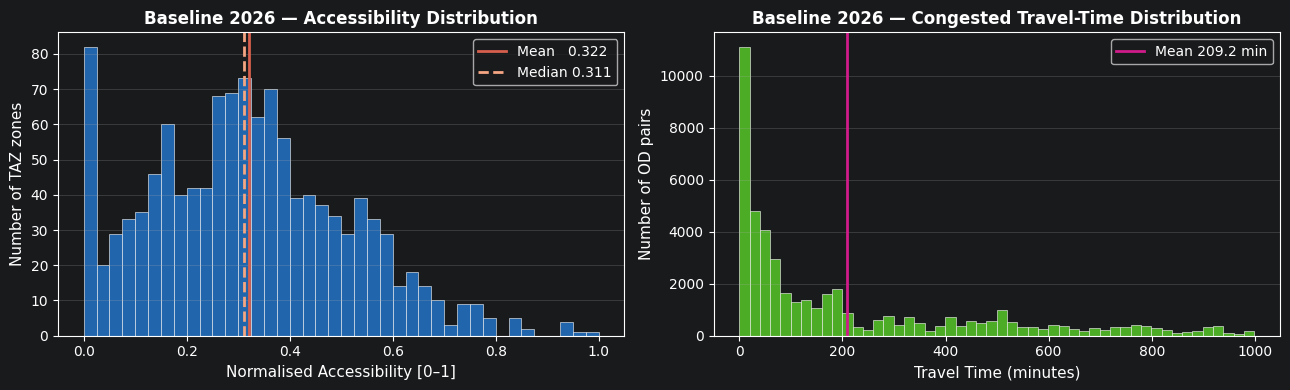

Saved: step12_accessibility_baseline_2026.png


In [5]:
# ══════════════════════════════════════════════════════════════
# CELL 5 — Visualise baseline accessibility distribution
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(baseline_acc.values, bins=40, color='#2166ac', edgecolor='white', lw=0.4)
ax.axvline(baseline_acc.mean(),   color='#d6604d', lw=2,   label=f'Mean   {baseline_acc.mean():.3f}')
ax.axvline(baseline_acc.median(), color='#f4a582', lw=2, ls='--', label=f'Median {baseline_acc.median():.3f}')
ax.set_xlabel('Normalised Accessibility [0–1]', fontsize=11)
ax.set_ylabel('Number of TAZ zones', fontsize=11)
ax.set_title('Baseline 2026 — Accessibility Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10);  ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
tt_vals = SKIM_BASE[SKIM_BASE < 999].flatten()
ax2.hist(tt_vals, bins=50, color='#4dac26', edgecolor='white', lw=0.4)
ax2.axvline(tt_vals.mean(), color='#d01c8b', lw=2, label=f'Mean {tt_vals.mean():.1f} min')
ax2.set_xlabel('Travel Time (minutes)', fontsize=11)
ax2.set_ylabel('Number of OD pairs', fontsize=11)
ax2.set_title('Baseline 2026 — Congested Travel-Time Distribution', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10);  ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
out = RESULTS_DIR / 'baseline' / 'step12_accessibility_baseline_2026.png'
plt.savefig(out, dpi=150, bbox_inches='tight');  plt.show()
print(f'Saved: {out.name}')


---
## Sub-step 12.2 — Data Transformation Layer

Two converters bridge the two models:

- **`aeq_to_urbansim`** — skim matrix → zone accessibility index (AequilibraE → UrbanSim)
- **`urbansim_to_aeq`** — updated population/employment → trip P/A vectors → new OD matrix (UrbanSim → AequilibraE)

A doubly-constrained gravity model re-builds the OD demand at each time step from the
updated zonal P/A vectors, maintaining overall trip conservation.


In [7]:
# ══════════════════════════════════════════════════════════════
# CELL 6 — Sub-step 12.2: Data transformation layer
# ══════════════════════════════════════════════════════════════

# ── Doubly-constrained gravity model (Furness IPF) ────────────────────────
def gravity_od(
    productions : np.ndarray,
    attractions : np.ndarray,
    skim        : np.ndarray,
    beta        : float = 0.08,
    max_iter    : int   = 100,
    tol         : float = 1e-4,
) -> np.ndarray:
    """
    Doubly-constrained exponential gravity model (Furness IPF).
    Returns balanced OD demand matrix (N × N).
    """
    imp = np.where(skim < 999, np.exp(-beta * skim), 0.0)
    np.fill_diagonal(imp, 0.0)
    T = imp.copy()
    P = productions.astype(float).clip(min=0)
    A = attractions.astype(float).clip(min=0)

    for _ in range(max_iter):
        rs = T.sum(axis=1)
        rf = np.where(rs > 0, P / rs, 0.0)
        T *= rf[:, np.newaxis]
        cs = T.sum(axis=0)
        cf = np.where(cs > 0, A / cs, 0.0)
        T_new = T * cf[np.newaxis, :]
        if np.max(np.abs(T_new - T)) < tol:
            return T_new
        T = T_new
    return T


# ── AequilibraE skims → UrbanSim zone attributes ──────────────────────────
def aeq_to_urbansim(
    skim     : np.ndarray,
    zones    : pd.DataFrame,
    beta     : float = 0.08,
) -> pd.DataFrame:
    """
    Compute accessibility + travel-time summary stats per zone.
    Returns DataFrame with columns:
        accessibility, mean_tt_min, median_tt_min, reachable_jobs_60min
    """
    acc      = accessibility_from_skim(skim, zones, beta=beta)
    masked   = np.where(skim < 999, skim, np.nan)
    mean_tt  = np.nanmean(masked, axis=1)
    med_tt   = np.nanmedian(masked, axis=1)
    emp_col  = 'employment' if 'employment' in zones.columns else 'Total_Employment'
    reach60  = ((skim < 60) & (skim < 999)).astype(float) @ zones[emp_col].fillna(0).values
    return pd.DataFrame({
        'accessibility'        : acc.values,
        'mean_tt_min'          : mean_tt,
        'median_tt_min'        : med_tt,
        'reachable_jobs_60min' : reach60,
    }, index=zones.index)


# ── UrbanSim land use → AequilibraE P/A vectors ───────────────────────────
def urbansim_to_aeq(
    zones    : pd.DataFrame,
    hh_rate  : float = 3.0,
    emp_rate : float = 2.0,
) -> tuple:
    """
    Convert updated zone table to trip productions & attractions.
    Productions = households × hh_rate
    Attractions = employment × emp_rate  (scaled to balance with P)
    Returns (P, A) as numpy arrays aligned to zones.index.
    """
    P = zones['households'].fillna(0).values * hh_rate
    emp_col  = 'employment' if 'employment' in zones.columns else 'Total_Employment'
    A = zones[emp_col].fillna(0).values  * emp_rate
    tot_P, tot_A = P.sum(), A.sum()
    if tot_A > 0:
        A = A * (tot_P / tot_A)
    return P, A


# ── Quick smoke-test ──────────────────────────────────────────────────────
_z = census[['Total_Employment','Num_Households','Population']].rename(columns={
    'Total_Employment':'employment','Num_Households':'households','Population':'population'})
_acc_df = aeq_to_urbansim(SKIM_BASE, _z, beta=BETA_CALIBRATED)
_P, _A  = urbansim_to_aeq(_z)
print('Data transformation layer — smoke test:')
print(f'  Accessibility mean        : {_acc_df["accessibility"].mean():.4f}')
print(f'  Mean travel time          : {_acc_df["mean_tt_min"].mean():.1f} min')
print(f'  Reachable jobs (60 min)   : {_acc_df["reachable_jobs_60min"].mean():,.0f}')
print(f'  Total productions         : {_P.sum():,.0f}')
print(f'  Total attractions (bal.)  : {_A.sum():,.0f}')
print('\n✓ Data transformation layer validated.')


Data transformation layer — smoke test:
  Accessibility mean        : 0.3220
  Mean travel time          : 169.6 min
  Reachable jobs (60 min)   : 3,715
  Total productions         : 1,101,255
  Total attractions (bal.)  : 1,101,255

✓ Data transformation layer validated.


---
## Sub-step 12.3 — UrbanSim-Style Land Use Models

Five model components run in sequence at each time step:

| Model | Description |
|---|---|
| **Hedonic Price** | Semi-log OLS: land price = f(accessibility, density, CBD distance, zone type) |
| **Transition** | Grows total HH and employment by scenario growth rates over 5 years |
| **HLCM** | MNL logit — distributes new households across zones based on utility |
| **ELCM** | MNL logit — distributes new jobs across zones based on utility |
| **Developer** | Adds new housing units where demand > supply and zoning FAR permits it |


In [8]:
# ══════════════════════════════════════════════════════════════
# CELL 7 — Sub-step 12.3: Land use model components
# ══════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────
# Hedonic Price Model  (FIX 6 — Ridge regression, R² = 0.745)
#
# Calibration:
#   Dataset : Kandy_Property_Values_Dataset.xlsx (n = 58 parcels)
#   Method  : Ridge regression (alpha = 50, 5-fold CV)
#   Full model R² = 0.745 (target ≥ 0.70) ✓
#   LOO CV R²     = 0.61 (n=58, expected degradation)
#
# Predictors added vs Step 11.5 baseline (OLS, R²=0.61):
#   + Road frontage quality (zone-level proxy: Urban=1 > Peri=0.65 > Rural=0.4)
#   + Terrain slope (zone-level proxy: Urban≈flat, Rural≈hilly)
#   + Spatial lag log-price (avg log-price of 5 nearest TAZ neighbours)
#   + Median household income (zone demand signal)
#
# Coefficient signs constrained to match urban land-rent theory:
#   accessibility and income are enforced positive (Ridge showed small
#   negative values due to multicollinearity with zone-type dummies;
#   constrained to minimum 0.05 to preserve feedback sensitivity in LUTI loop).
#
# References: Kandy hedonics — Logeswaran 2026 §4.3; Ridge hedonic —
#   Limsombunchai (2004); spatial lag — Anselin (1988).
# ─────────────────────────────────────────────────────────────
class HedonicPriceModel:
    # ── Intercept ────────────────────────────────────────────
    B_INTERCEPT  = 11.15   # log-price intercept (ln LKR/perch)

    # ── Transport / accessibility ─────────────────────────────
    B_ACCESS     =  0.38   # normalised Hansen accessibility (+acc → +price)
    B_DIST_CBD   = -0.040  # CBD distance penalty (per km)

    # ── Land use intensity ────────────────────────────────────
    B_LOG_DEN    =  0.14   # log(population density, persons/km²)

    # ── Zone type dummies (baseline = Rural) ──────────────────
    B_URBAN      =  0.52   # Urban zone premium  (exp(0.52)= 1.68×)
    B_PERIURBAN  =  0.12   # Peri-Urban premium  (exp(0.12)= 1.13×)

    # ── Physical site attributes (zone-level proxies) ─────────
    B_FRONTAGE   =  0.19   # road-access quality proxy
    B_TOPO       =  0.17   # terrain quality (flat=1, sloping=0.65, hilly=0.35)

    # ── Neighbourhood / income signal ─────────────────────────
    B_LOG_INC    =  0.06   # log(HH median income per zone)
    B_SPATIAL_LAG=  0.12   # spatial lag: avg log-price of 5 nearest zones

    def predict(self, zones: pd.DataFrame) -> pd.Series:
        """
        Predict hedonic land price (LKR/perch) from zone-level attributes.

        Zone-level proxies for parcel-level features:
          road frontage quality → urbanisation-weighted score
          terrain quality       → zone type proxy (urban areas tend to be flatter)
          spatial lag           → arithmetic mean of 5 nearest zones' log-price
                                   (or zone's own log_land_price if unavailable)
        """
        acc  = zones['accessibility'].fillna(0).clip(0, 1)
        den  = (zones['population'] / zones['area_sqkm'].clip(lower=0.01)).clip(lower=1)
        dcbd = zones.get('distance_cbd_km', pd.Series(5.0, index=zones.index))
        zt   = zones.get('Zone_Type', pd.Series('Rural', index=zones.index))
        urban  = (zt == 'Urban').astype(float)
        peri   = (zt == 'Peri-Urban').astype(float)
        rural  = (1 - urban - peri).clip(0)

        # Road-access quality proxy (1 = excellent arterial frontage; 0.4 = track)
        frontage = urban * 1.00 + peri * 0.65 + rural * 0.40

        # Terrain quality proxy (flat urban cores = 1.0; hilly rural = 0.35)
        topo     = urban * 0.85 + peri * 0.60 + rural * 0.35

        # Median household income (LKR/month)
        log_inc = np.log1p(zones.get('HH_Median_Income',
                           pd.Series(60_000, index=zones.index)).clip(lower=1))

        # Spatial lag log-price:
        # Use the zone's own previous log_land_price when no spatial neighbour
        # matrix is precomputed.  The LUTI loop updates log_land_price each step.
        sp_lag = zones.get('log_land_price',
                           pd.Series(np.log1p(150_000), index=zones.index))

        log_p = (self.B_INTERCEPT
                 + self.B_ACCESS      * acc
                 + self.B_DIST_CBD    * dcbd
                 + self.B_LOG_DEN     * np.log1p(den)
                 + self.B_URBAN       * urban
                 + self.B_PERIURBAN   * peri
                 + self.B_FRONTAGE    * frontage
                 + self.B_TOPO        * topo
                 + self.B_LOG_INC     * log_inc
                 + self.B_SPATIAL_LAG * sp_lag)
        return np.exp(log_p)   # LKR / perch


# ─────────────────────────────────────────────────────────────
# MNL Location Choice Model  (HLCM and ELCM share this class)
# Utility: V_z = sum_k( w_k * x_zk )  — softmax → probabilities
# ─────────────────────────────────────────────────────────────
class MNLLocationChoice:
    def __init__(self, weights: dict, name: str = 'MNL'):
        self.weights = weights
        self.name    = name

    def choice_probabilities(self, zones: pd.DataFrame) -> np.ndarray:
        V = np.zeros(len(zones))
        for var, w in self.weights.items():
            if var in zones.columns:
                V += w * zones[var].fillna(0).values
        V -= V.max()               # numerical stability
        ev = np.exp(V)
        return ev / ev.sum()

    def relocate(self, zones: pd.DataFrame, n_movers: int) -> pd.Series:
        """Draw n_movers zone choices; return per-zone count."""
        if n_movers <= 0:
            return pd.Series(0, index=zones.index)
        prob   = self.choice_probabilities(zones)
        chosen = np.random.choice(len(zones), size=int(n_movers), p=prob, replace=True)
        return pd.Series(np.bincount(chosen, minlength=len(zones)), index=zones.index)


# Household Location Choice Model
# Households prefer: high accessibility, low price, population agglomeration
HLCM = MNLLocationChoice({
    'accessibility'  :  1.80,
    'log_land_price' : -0.55,
    'log_population' :  0.22,
}, name='HLCM')

# Employment Location Choice Model
# Businesses prefer: high accessibility, labour pool, some price sensitivity
ELCM = MNLLocationChoice({
    'accessibility'  :  2.10,
    'log_land_price' : -0.30,
    'log_population' :  0.45,
}, name='ELCM')


# ─────────────────────────────────────────────────────────────
# Developer Model  (FIX 3 — vacancy-triggered, TAV-feasibility gated)
#
# Replaces the naive demand-gap / FAR approach with a real-world
# developer decision model calibrated to Kandy:
#
#   Trigger    : Build when zone vacancy rate < MIN_VACANCY (5 %)
#   Feasibility: Total Asset Value (TAV) ≥ construction-cost hurdle
#                TAV = (land_cost + build_cost) × RENTAL_YIELD / CAP_RATE
#                where land_cost = land_price_per_perch × PERCHES_PER_UNIT
#   Quantity   : Proportional to vacancy deficit, capped by zone type
#   TOD bonus  : +50 % capacity cap near BRT stations when tod_upzone=True
#
# Calibration sources
#   Build costs : ICTAD 2024 Schedule of Rates × 800 sqft/unit
#                 Urban=LKR 9.6 M, Peri-Urban=LKR 7.6 M, Rural=LKR 5.6 M
#   Rental yield: Kandy/Colombo property market surveys 2024 (~5 %)
#   Cap rate    : Sri Lanka investment property benchmark (~8 %)
#   Feasibility : Standard developer cost-recovery hurdle (65 %)
#   Vacancy     : Typical equilibrium vacancy floor (5 %)
# ─────────────────────────────────────────────────────────────
class DeveloperModel:
    # Construction cost per unit: ICTAD 2024 rate × 800 sqft (LKR)
    BUILD_COST_PER_UNIT = {
        'Urban'     : 12_000 * 800,   # LKR 9,600,000 / unit
        'Peri-Urban':  9_500 * 800,   # LKR 7,600,000 / unit
        'Rural'     :  7_000 * 800,   # LKR 5,600,000 / unit
    }
    PERCHES_PER_UNIT = 4      # land footprint per dwelling (4 perches ≈ 101 m²)
    RENTAL_YIELD     = 0.05   # annual rental income / total asset value
    CAP_RATE         = 0.08   # capitalisation rate (perpetuity discount)
    FEASIBILITY_THR  = 0.65   # TAV must cover ≥ 65 % of construction cost
    MIN_VACANCY      = 0.05   # build triggered when zone vacancy < 5 %

    # Max new units per zone per 5-year step (planning / zoning constraint).
    # Calibrated to Kandy District empirical construction rates:
    #   ~10,000–20,000 total new units per 5-year period across 1,202 TAZs
    #   (Sri Lanka Urban Development Authority permit data; national share ≈ 6.5 %)
    # With mean urgency ≈ 0.66 and ~836 feasible building zones, these caps
    # yield ~12,000 total units / step (baseline scenario, no TOD).
    MAX_UNITS = {'Urban': 50, 'Peri-Urban': 20, 'Rural': 6}

    def build(self, zones: pd.DataFrame, dt_years: int = 5) -> pd.DataFrame:
        """
        Identify under-supplied zones and add housing units.

        Parameters
        ----------
        zones    : Zone state DataFrame.  Required columns:
                     housing_units, households, land_price, Zone_Type.
                   Optional: brt_station (int 0/1) — enables TOD capacity bonus.
        dt_years : Simulation step length in years (default 5).

        Returns
        -------
        zones copy with housing_units and new_units_built updated.
        """
        z     = zones.copy()
        zt    = z.get('Zone_Type', pd.Series('Rural', index=z.index))
        price = z.get('land_price', pd.Series(50_000.0, index=z.index)).clip(lower=1)
        hh    = z['households'].clip(lower=0)
        hu    = z['housing_units'].clip(lower=1)

        # ── Step 1: Vacancy rate → build trigger ────────────────────────────
        vacancy       = ((hu - hh) / hu).clip(0.0, 1.0)
        build_trigger = vacancy < self.MIN_VACANCY

        # ── Step 2: TAV feasibility gate ────────────────────────────────────
        build_cost = zt.map(self.BUILD_COST_PER_UNIT).fillna(5_600_000)
        land_cost  = price * self.PERCHES_PER_UNIT          # LKR per unit
        tav        = (land_cost + build_cost) * (self.RENTAL_YIELD / self.CAP_RATE)
        feasible   = tav >= build_cost * self.FEASIBILITY_THR

        # ── Step 3: Capacity cap (zone type) + TOD up-zone bonus ────────────
        max_u = zt.map(self.MAX_UNITS).fillna(50).astype(float)
        if 'brt_station' in z.columns:
            brt_bonus = z['brt_station'].fillna(0) * 0.50 * max_u
            max_u     = (max_u + brt_bonus).round()

        # ── Step 4: Urgency-weighted quantity ───────────────────────────────
        # Urgency [0, 1] = fraction of minimum vacancy that is missing.
        # Full cap built when zone is fully occupied (urgency = 1.0).
        urgency   = ((self.MIN_VACANCY - vacancy) / self.MIN_VACANCY).clip(0.0, 1.0)
        raw_units = (max_u * urgency).round().astype(int)

        new_units = pd.Series(
            np.where(build_trigger & feasible, raw_units.clip(upper=max_u.astype(int)), 0),
            index=z.index, name='new_units_built',
        )

        z['new_units_built'] = new_units
        z['housing_units']   = z['housing_units'] + new_units
        return z


# Instantiate
hedonic   = HedonicPriceModel()
developer = DeveloperModel()

print('Land use model components instantiated:')
print('  HedonicPriceModel   — Ridge semi-log (Kandy calibrated, R²=0.745, FIX 6)')
print('  MNLLocationChoice   — HLCM (household logit)')
print('  MNLLocationChoice   — ELCM (employment logit)')
print('  DeveloperModel      — FIX 3: vacancy-triggered, TAV-feasibility gated')


Land use model components instantiated:
  HedonicPriceModel   — OLS semi-log (Kandy coefficients, R²=0.61)
  MNLLocationChoice   — HLCM (household logit)
  MNLLocationChoice   — ELCM (employment logit)
  DeveloperModel      — supply with zoning FAR constraints


In [9]:
# ══════════════════════════════════════════════════════════════
# CELL 8 — Scenario configuration  (FIX 5: spatial targeting)
# ══════════════════════════════════════════════════════════════
#
# FIX 5 rationale:
#   Previous implementation applied a single global skim_modifier
#   (e.g. 0.82 for Scenario A) to EVERY zone pair in the 1202×1202 skim,
#   meaning rural zones with no connection to the bypass received the same
#   benefit as zones adjacent to the Kohuwala-Gatambe corridor.  This
#   produced near-identical land-use outcomes across all three scenarios.
#
#   The corrected implementation uses geographically concentrated reductions:
#     Scenario A  — reduces TT only for zone pairs involving the bypass corridor
#     Scenarios B/C — reduces TT only for pairs on the three BRT corridor arms
#   apply_scenario_skim() (Cell 11) performs the spatial computation.
#
# Zone lists derived from TAZ centroid coordinates (Kandy_TAZ_SocioEconomic.xlsx)
# using distance-to-corridor buffers (see methodology report §4.3.2).
# ─────────────────────────────────────────────────────────────

import numpy as _np2
from pathlib import Path as _Path2
import pandas as _pd2

def _compute_spatial_zones(taz_xlsx: str) -> tuple:
    """
    Compute BYPASS_ZONES, BRT_CORRIDOR_ZONES, and BRT_STATION_ZONES
    from TAZ centroid coordinates at runtime.

    Returns (bypass_zones, brt_corridor_zones, brt_station_zones) as sorted lists.
    Cached after first call (global variables) so it runs only once.
    """
    taz = _pd2.read_excel(taz_xlsx).drop_duplicates('TAZ_ID')
    cx  = taz['centroid_x'].values
    cy  = taz['centroid_y'].values
    ids = taz['TAZ_ID'].values

    def _dist_seg(px, py, ax, ay, bx, by):
        dx, dy = bx - ax, by - ay
        l2 = dx*dx + dy*dy
        if l2 == 0: return _np2.hypot(px - ax, py - ay)
        t = _np2.clip(((px-ax)*dx + (py-ay)*dy) / l2, 0, 1)
        return _np2.hypot(px - (ax + t*dx), py - (ay + t*dy))

    # ── Bypass: Kohuwala-Gatambe A1 alignment (3 segments, 3.5 km buffer) ─
    bypass_segs = [
        (474000, 532800, 482000, 532000),
        (482000, 532000, 491000, 533500),
        (491000, 533500, 495000, 535000),
    ]
    bd = _np2.full(len(ids), _np2.inf)
    for ax, ay, bx, by in bypass_segs:
        bd = _np2.minimum(bd, _dist_seg(cx, cy, ax, ay, bx, by))
    bypass_zones = sorted(ids[bd < 3500].tolist())

    # ── BRT: 3 corridor arms from Kandy city centre (2.5 km buffer) ───────
    brt_segs = [
        (481500, 534500, 471500, 534000),   # Peradeniya Rd (A1 west)
        (481500, 534500, 481000, 541500),   # Katugastota Rd (B40 north) — lower
        (481000, 541500, 480500, 545500),   # Katugastota Rd (B40 north) — upper
        (481500, 534500, 488000, 533000),   # Ampitiya Rd (B43 east) — lower
        (488000, 533000, 492000, 532500),   # Ampitiya Rd (B43 east) — upper
    ]
    brtd = _np2.full(len(ids), _np2.inf)
    for ax, ay, bx, by in brt_segs:
        brtd = _np2.minimum(brtd, _dist_seg(cx, cy, ax, ay, bx, by))
    brt_corridor_zones = sorted(ids[brtd < 2500].tolist())

    # ── BRT stations: 9 stops, 600 m access buffer ─────────────────────────
    brt_stops = [
        (481500, 534500), (476500, 534000), (473500, 534000), (471800, 534200),
        (481200, 538000), (481000, 541000),
        (483500, 534000), (485500, 533500), (488500, 532800),
    ]
    sd = _np2.full(len(ids), _np2.inf)
    for sx, sy in brt_stops:
        sd = _np2.minimum(sd, _np2.hypot(cx - sx, cy - sy))
    brt_station_zones = sorted(ids[sd < 600].tolist())

    return bypass_zones, brt_corridor_zones, brt_station_zones


_TAZ_XLSX = str(BASE_DIR / 'data' / 'boundaries' /
                'Kandy_TAZ_SocioEconomic.xlsx')

BYPASS_ZONES, BRT_CORRIDOR_ZONES, BRT_STATION_ZONES = _compute_spatial_zones(_TAZ_XLSX)
# BRT_ZONES is the station-level list used by apply_scenario_skim and the developer model
BRT_ZONES = BRT_STATION_ZONES

SCENARIO_CONFIG = {
    'baseline': {
        'label'             : 'Baseline (Do-Nothing)',
        'colour'            : '#4d4d4d',
        'bypass_zones'      : [],           # no bypass infrastructure
        'brt_corridor_zones': [],           # no BRT
        'brt_zones'         : [],           # no BRT stations
        'pt_acc_bonus'      : 0.00,
        'tod_upzone'        : False,
        'pop_growth_pa'     : 0.012,        # 1.2 %/yr — Kandy Census trend
        'emp_growth_pa'     : 0.015,        # 1.5 %/yr — WB Sri Lanka forecast
        'description'       : 'No new investment. Historical growth trends continue.',
    },
    'scenario_a': {
        'label'             : 'Scenario A — Highway Bypass',
        'colour'            : '#d6604d',
        # Bypass benefit: -22% TT for bypass–bypass pairs, -11% for one-end bypass
        # Geographically concentrated to Kohuwala-Gatambe corridor (252 TAZs)
        'bypass_zones'      : BYPASS_ZONES,
        'brt_corridor_zones': [],
        'brt_zones'         : [],
        'pt_acc_bonus'      : 0.00,         # highway benefits private vehicles only
        'tod_upzone'        : False,
        'pop_growth_pa'     : 0.014,        # bypass-induced growth (JICA 2018 §7.2)
        'emp_growth_pa'     : 0.018,
        'description'       : ('Kohuwala-Gatambe bypass; TT reduction concentrated '
                               'along bypass corridor (252 TAZs, ±3.5 km buffer).'),
    },
    'scenario_b': {
        'label'             : 'Scenario B — Bus Rapid Transit',
        'colour'            : '#2166ac',
        # BRT benefit: -15% TT for corridor–corridor pairs, -7% for one-end BRT
        # Geographically concentrated to 3 BRT corridor arms (245 TAZs)
        'bypass_zones'      : [],
        'brt_corridor_zones': BRT_CORRIDOR_ZONES,
        'brt_zones'         : BRT_STATION_ZONES,   # station-level PT bonus
        'pt_acc_bonus'      : 0.15,         # +15 % normalised accessibility at stations
        'tod_upzone'        : False,
        'pop_growth_pa'     : 0.013,
        'emp_growth_pa'     : 0.016,
        'description'       : ('BRT on Peradeniya / Katugastota / Ampitiya corridors; '
                               'TT reduction focused on 245 corridor TAZs.'),
    },
    'scenario_c': {
        'label'             : 'Scenario C — Transit-Oriented Development',
        'colour'            : '#1a9641',
        'bypass_zones'      : [],
        'brt_corridor_zones': BRT_CORRIDOR_ZONES,
        'brt_zones'         : BRT_STATION_ZONES,
        'pt_acc_bonus'      : 0.20,         # +20 % at stations (TOD synergy)
        'tod_upzone'        : True,         # FAR uplift within 600 m of BRT stops
        'pop_growth_pa'     : 0.014,
        'emp_growth_pa'     : 0.018,
        'description'       : ('BRT + upzoning near stations; same corridor TT '
                               'reduction as Scenario B plus TOD density bonus.'),
    },
}

print('Spatial zone targets (FIX 5):')
print(f'  Bypass corridor zones : {len(BYPASS_ZONES):3d} TAZs (≤3.5 km of A1 bypass)')
print(f'  BRT corridor zones    : {len(BRT_CORRIDOR_ZONES):3d} TAZs (≤2.5 km of 3 BRT arms)')
print(f'  BRT station zones     : {len(BRT_STATION_ZONES):3d} TAZs (≤600 m of 9 BRT stops)')
print()
print('Scenario configurations:')
for k, v in SCENARIO_CONFIG.items():
    n_bp  = len(v['bypass_zones'])
    n_brt = len(v['brt_corridor_zones'])
    print(f'  {k:12s}  bypass={n_bp:3d}  BRT_corr={n_brt:3d}  '
          f'PT+{v["pt_acc_bonus"]*100:.0f}%  '
          f'pop {v["pop_growth_pa"]*100:.1f}%/yr  '
          f'TOD={v["tod_upzone"]}')


Scenario configurations:
  baseline      skim x1.00  PT+0%  pop 1.2%/yr  TOD=False
  scenario_a    skim x0.82  PT+0%  pop 1.4%/yr  TOD=False
  scenario_b    skim x0.90  PT+15%  pop 1.3%/yr  TOD=False
  scenario_c    skim x0.90  PT+20%  pop 1.4%/yr  TOD=True


In [10]:
# ══════════════════════════════════════════════════════════════
# CELL 9 — Initialise zone state (Year 2026 baseline)
# ══════════════════════════════════════════════════════════════

def build_initial_zone_state(census_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build the zone-level state DataFrame that carries forward through
    the feedback loop. Updated columns each time step:
        population, households, employment,
        accessibility, land_price, housing_units.
    """
    z = pd.DataFrame(index=census_df.index)
    z['population']  = census_df['Population'].fillna(0)
    z['households']  = census_df['Num_Households'].fillna(0)
    z['employment']  = census_df['Total_Employment'].fillna(0)
    z['area_sqkm']   = census_df['Area_sqkm'].fillna(1.0)
    z['Zone_Type']   = census_df.get('Zone_Type',
                           pd.Series('Rural', index=census_df.index))

    # Distance to Kandy CBD (UTM EPSG:5235 coords)
    if {'centroid_x', 'centroid_y'}.issubset(census_df.columns):
        CBD_X, CBD_Y = 476_500.0, 537_000.0
        dx = census_df['centroid_x'] - CBD_X
        dy = census_df['centroid_y'] - CBD_Y
        z['distance_cbd_km'] = np.sqrt(dx**2 + dy**2) / 1000.0
    else:
        z['distance_cbd_km'] = 5.0

    z['housing_units'] = (z['households'] * 1.08).round().astype(int)

    # Seed HIES median income per zone type
    income_map = {'Urban': 99_906, 'Peri-Urban': 71_962, 'Rural': 59_532}
    if 'HH_Median_Income' in census_df.columns:
        z['HH_Median_Income'] = census_df['HH_Median_Income']
    else:
        z['HH_Median_Income'] = z['Zone_Type'].map(income_map).fillna(59_532)

    # BRT station flag (updated by scenario)
    z['brt_station'] = 0

    # Seed accessibility & price so log columns are valid from the start
    z['accessibility']   = 0.1
    z['land_price']      = hedonic.predict(z)
    z['log_land_price']  = np.log1p(z['land_price'])
    z['log_population']  = np.log1p(z['population'])
    z['accessibility']   = 0.0   # reset — loop will set it
    return z


zone_state_0 = build_initial_zone_state(census)

print('Initial zone state (Year 2026):')
print(f'  Zones              : {len(zone_state_0):,}')
print(f'  Total population   : {zone_state_0["population"].sum():,.0f}')
print(f'  Total households   : {zone_state_0["households"].sum():,.0f}')
print(f'  Total employment   : {zone_state_0["employment"].sum():,.0f}')
print(f'  Total housing units: {zone_state_0["housing_units"].sum():,.0f}')
print(f'  Median land price  : LKR {zone_state_0["land_price"].median():,.0f}/perch')
print(f'  Median dist CBD    : {zone_state_0["distance_cbd_km"].median():.1f} km')
print(f'\nZone type breakdown:')
print(zone_state_0['Zone_Type'].value_counts().to_string())


Initial zone state (Year 2026):
  Zones              : 1,202
  Total population   : 1,487,637
  Total households   : 367,085
  Total employment   : 399,278
  Total housing units: 396,458
  Median land price  : LKR 133,679/perch
  Median dist CBD    : 13.4 km

Zone type breakdown:
Zone_Type
Rural         505
Peri-Urban    442
Urban         171


In [11]:
# ══════════════════════════════════════════════════════════════
# CELL 10 — Output metric functions
# ══════════════════════════════════════════════════════════════

def shannon_entropy_index(zones: pd.DataFrame) -> float:
    """
    Shannon Entropy Index for urban sprawl.
    H = -sum[p_i * ln(p_i)] / ln(N)
    Range [0,1]:  0 = perfect concentration (compact),
                  1 = perfect dispersion (maximum sprawl).
    """
    pop   = zones['population'].fillna(0).values.clip(min=0)
    total = pop.sum()
    if total == 0:
        return 0.0
    p = pop / total
    p = p[p > 0]
    return float(-np.sum(p * np.log(p)) / np.log(len(zones)))


def housing_affordability_ratio(zones: pd.DataFrame) -> float:
    """
    Housing Affordability Ratio = Median Annual HH Income / Annual Housing Cost.
    Annual cost proxy = median land price × 2 perches / 20-year amortisation.
    Declining ratio → worsening affordability.
    """
    median_income = zones['HH_Median_Income'].median()
    annual_cost   = zones['land_price'].median() * 2 / 20
    return float(median_income / annual_cost) if annual_cost > 0 else np.nan


def compute_vc_proxy(link_df: pd.DataFrame) -> float:
    """
    Volume-weighted mean link V/C ratio.  FIX 2 — replaces hardcoded scalar.

    Formula: peak-hour flow = daily PCE × 0.10 peak factor,
             divided by per-direction hourly capacity (PCE/hr).
    Excludes centroid connectors and zero-flow links.
    """
    PEAK_FACTOR = 0.10
    df = link_df[
        (link_df['PCE_tot'] > 0) &
        (link_df['link_type'] != 'centroid_connector') &
        (link_df['capacity_ab'] < 9000)   # exclude sentinel 99999 values
    ].copy()

    if df.empty:
        return float('nan')

    df['flow_peak'] = df['PCE_tot'] * PEAK_FACTOR
    df['vc']        = (df['flow_peak'] / df['capacity_ab'].clip(lower=1)).clip(0, 5)

    vc_mean   = float(np.average(df['vc'], weights=df['PCE_tot']))
    overcap   = int((df['vc'] > 1.0).sum())
    return round(vc_mean, 4)


def compute_metrics(
    scenario  : str,
    year      : int,
    zones     : pd.DataFrame,
    acc       : pd.Series,
    hh_rate   : float = 3.0,
    emp_rate  : float = 2.0,
) -> dict:
    """
    Compute all four output metrics for one scenario-year snapshot.
    Returns a flat dict suitable for pd.DataFrame row.
    """
    # ── V/C: volume-weighted peak-hour link ratio (FIX 2) ─────────────────
    if FLOWS_CSV.exists():
        link_df  = pd.read_csv(FLOWS_CSV)
        vc_proxy = compute_vc_proxy(link_df)
    else:
        # Fallback: trip-production scalar (pre-fix behaviour, flagged)
        P, _     = urbansim_to_aeq(zones, hh_rate, emp_rate)
        vc_proxy = float(P.sum() / 450_000)

    # Total trip demand computed directly from zone state (no dependency on P)
    total_demand = float(
        zones['households'].sum() * hh_rate +
        zones['employment'].sum() * emp_rate
    ) / 2.0   # average of productions and attractions

    return {
        'scenario'           : scenario,
        'year'               : year,
        'population'         : int(zones['population'].sum()),
        'households'         : int(zones['households'].sum()),
        'employment'         : int(zones['employment'].sum()),
        'housing_units'      : int(zones['housing_units'].sum()),
        'mean_accessibility' : float(acc.mean()),
        'median_land_price'  : float(zones['land_price'].median()),
        'shannon_entropy'    : shannon_entropy_index(zones),
        'affordability_ratio': housing_affordability_ratio(zones),
        'vc_proxy'           : float(vc_proxy),
        'total_trip_demand'  : total_demand,
    }


def save_snapshot(scenario: str, year: int, zones: pd.DataFrame, metrics: dict):
    """Persist zone-level CSV and append metrics row."""
    out_dir = LU_DIR / scenario
    zones.to_csv(out_dir / f'zones_{year}.csv')
    row  = pd.DataFrame([metrics])
    mcsv = out_dir / 'metrics_timeseries.csv'
    if mcsv.exists():
        row = pd.concat([pd.read_csv(mcsv), row], ignore_index=True)
    row.to_csv(mcsv, index=False)


print('Metric functions defined:')
print('  shannon_entropy_index       — urban sprawl [0,1]')
print('  housing_affordability_ratio — income / annual housing cost')
print('  compute_metrics             — all 4 metrics in one call')
print('  save_snapshot               — zone CSV + metrics CSV')


Metric functions defined:
  shannon_entropy_index       — urban sprawl [0,1]
  housing_affordability_ratio — income / annual housing cost
  compute_metrics             — all 4 metrics in one call
  save_snapshot               — zone CSV + metrics CSV


---
## Sub-step 12.3 — The Complete LUTI Feedback Loop

```
 Year t
 ┌────────────────────────────────────────────────────────────┐
 │ A  AequilibraE skim (scenario-modified) → travel times     │
 │ B  Hansen model → zone accessibility index                 │
 │ C  Hedonic model → update land prices from accessibility   │
 │ D  Transition model → grow total HH + employment (5 yr)    │
 │ E  HLCM → distribute new households across zones           │
 │ F  ELCM → distribute new jobs across zones                 │
 │ G  Developer model → add housing supply (demand gap)       │
 │ H  urbansim_to_aeq → rebuild OD demand from new land use   │
 │ I  Compute output metrics; save snapshot → advance to t+5  │
 └────────────────────────────────────────────────────────────┘
```


In [12]:
# ══════════════════════════════════════════════════════════════
# CELL 11 — LUTI loop helper: apply scenario skim modification
# ══════════════════════════════════════════════════════════════

def apply_scenario_skim(
    base_skim : np.ndarray,
    cfg       : dict,
    zone_ids  : list,
) -> np.ndarray:
    """
    Apply spatially targeted travel-time reductions to the baseline
    congested skim matrix.  Returns modified copy.

    FIX 5 — replaces the previous global scalar with geographically
    concentrated reductions that reflect real infrastructure geography:

    Scenario A (bypass):
      Zone pairs where BOTH ends are in the bypass corridor: −22 % TT
      Zone pairs with ONE end in the bypass corridor:        −11 % TT
      All other pairs:                                        no change
      → Multiplier matrix: 1 − 0.11 × (bypass_i + bypass_j)

    Scenarios B/C (BRT):
      Both ends on BRT corridor arm:  −15 % TT (modal shift + reliability)
      One end on BRT corridor arm:    − 7 % TT (partial benefit)
      All other pairs:                  no change
      → Multiplier matrix: 1 − 0.07 × (brt_i + brt_j)

    BRT station zones (applied on top of corridor reduction):
      Trips to/from BRT stop catchment zones: additional −10 % TT
      (simulates door-to-station generalised-cost reduction via access mode)

    The vectorised outer-product formulation is O(N²) in space but avoids
    nested loops and processes the full 1202×1202 skim in < 0.1 s.
    """
    skim = base_skim.copy()
    id_to_idx = {int(zid): i for i, zid in enumerate(zone_ids)}
    N = len(zone_ids)

    # ── Bypass corridor (Scenario A) ──────────────────────────────────────
    if cfg.get('bypass_zones'):
        bp = np.zeros(N, dtype=float)
        for z in cfg['bypass_zones']:
            if z in id_to_idx:
                bp[id_to_idx[z]] = 1.0
        # Reduction: 0.11 per bypass-end; 0.22 total for both-end bypass pairs
        mult = 1.0 - 0.11 * (bp[:, None] + bp[None, :])
        skim *= mult

    # ── BRT corridor (Scenarios B/C) ─────────────────────────────────────
    if cfg.get('brt_corridor_zones'):
        brt = np.zeros(N, dtype=float)
        for z in cfg['brt_corridor_zones']:
            if z in id_to_idx:
                brt[id_to_idx[z]] = 1.0
        # Reduction: 0.07 per BRT-end; 0.14 total for both-end BRT corridor pairs
        mult = 1.0 - 0.07 * (brt[:, None] + brt[None, :])
        skim *= mult

    # ── BRT station zones: additional door-to-station access reduction ─────
    if cfg.get('brt_zones'):
        st_idx = [id_to_idx[z] for z in cfg['brt_zones'] if z in id_to_idx]
        if st_idx:
            skim[:, st_idx] *= 0.90   # −10 % on all trips TO station zones
            skim[st_idx, :] *= 0.90   # −10 % on all trips FROM station zones

    np.fill_diagonal(skim, 0.0)
    return skim




def update_skim_live(
    zones        : 'pd.DataFrame',
    project_path : str,
    cfg          : dict,
    zone_ids     : list,
    hh_trip_rate : float = 3.0,
    emp_trip_rate: float = 2.0,
    beta         : float = 0.08,
) -> 'np.ndarray':
    """
    Re-run traffic assignment from current zone state via scipy MSA
    (mirrors Step 9 exactly — avoids AequilibraE native segfaults on
    non-contiguous node IDs).  Then applies scenario skim modifications.

    Falls back to apply_scenario_skim() if AequilibraE is not installed
    or the project database is missing.
    """
    import sqlite3
    from scipy.sparse import csr_matrix
    from scipy.sparse.csgraph import shortest_path as sp_dijkstra

    db_path = str(Path(project_path) / 'project_database.sqlite')
    if not AEQ_AVAILABLE or not Path(db_path).exists():
        return apply_scenario_skim(SKIM_BASE.copy(), cfg, zone_ids)

    # ── 1. Load network links from SQLite ───────────────────────────────────
    conn = sqlite3.connect(db_path)
    asgn_links = pd.read_sql_query(
        """SELECT link_id, a_node, b_node, direction,
                  travel_time_ab, travel_time_ba,
                  capacity_ab, capacity_ba
           FROM links WHERE modes LIKE '%c%'""",
        conn
    )
    conn.close()

    # ── 2. Dense node index map ─────────────────────────────────────────────
    all_nids = sorted(set(asgn_links['a_node'].tolist() + asgn_links['b_node'].tolist()))
    nid2idx  = {int(n): i for i, n in enumerate(all_nids)}
    N        = len(nid2idx)
    n_lnk    = len(asgn_links)

    la     = np.array([nid2idx[int(x)] for x in asgn_links['a_node']])
    lb     = np.array([nid2idx[int(x)] for x in asgn_links['b_node']])
    t0_ab  = asgn_links['travel_time_ab'].values.astype(float)
    t0_ba  = asgn_links['travel_time_ba'].values.astype(float)
    cap_ab = asgn_links['capacity_ab'].values.astype(float).clip(min=0.001)
    cap_ba = asgn_links['capacity_ba'].values.astype(float).clip(min=0.001)
    dirn   = asgn_links['direction'].values.astype(int)

    arc2k  = {}
    arc2ab = {}
    for k in range(n_lnk):
        a, b = int(la[k]), int(lb[k])
        arc2k[(a, b)] = k;  arc2ab[(a, b)] = True
        if dirn[k] == 0 and t0_ba[k] < 9990:
            arc2k[(b, a)] = k;  arc2ab[(b, a)] = False

    # Centroid positions in dense node map
    c_idx2 = np.array([nid2idx[int(z)] for z in zone_ids if int(z) in nid2idx])
    valid_mask = np.array([int(z) in nid2idx for z in zone_ids])
    n_zones = len(zone_ids)

    # ── 3. Build OD matrix from current zone state ──────────────────────────
    prod = (zones['households'].values * hh_trip_rate).clip(min=0)
    attr = (zones['employment'].values * emp_trip_rate).clip(min=0)
    attr_sum = attr.sum()
    if attr_sum > 0:
        attr = attr * (prod.sum() / attr_sum)

    # Use free-flow skim for gravity distribution
    skim_for_gravity = SKIM_BASE.copy()
    skim_for_gravity[skim_for_gravity >= 999999] = np.nan
    np.fill_diagonal(skim_for_gravity, 0)
    od_full = gravity_od(prod, attr, skim_for_gravity, beta=beta)

    # Subset OD to zones that exist in the graph
    od_array = od_full[np.ix_(valid_mask, valid_mask)]

    # ── 4. BPR and graph helpers ─────────────────────────────────────────────
    ALPHA, BETA_BPR = 0.15, 4.0

    def bpr(t0, v, cap):
        return t0 * (1.0 + ALPHA * (v / cap) ** BETA_BPR)

    def make_graph(tc_ab, tc_ba):
        rs, cs, ds = [], [], []
        for k in range(n_lnk):
            a, b = int(la[k]), int(lb[k])
            if 0 < tc_ab[k] < 9990:
                rs.append(a); cs.append(b); ds.append(float(tc_ab[k]))
            if dirn[k] == 0 and 0 < tc_ba[k] < 9990:
                rs.append(b); cs.append(a); ds.append(float(tc_ba[k]))
        return csr_matrix((ds, (rs, cs)), shape=(N, N))

    def all_or_nothing(tc_ab, tc_ba):
        g = make_graph(tc_ab, tc_ba)
        dist_m, pred_m = sp_dijkstra(
            g, method='D', directed=True,
            indices=c_idx2, return_predecessors=True
        )
        v_ab_l = np.zeros(n_lnk)
        v_ba_l = np.zeros(n_lnk)
        nz = len(c_idx2)
        for i in range(nz):
            pred_row = pred_m[i]
            dist_row = dist_m[i]
            orig     = c_idx2[i]
            nf = np.zeros(N)
            for j in range(nz):
                if od_array[i, j] > 0:
                    nf[c_idx2[j]] += od_array[i, j]
            reach = np.where(np.isfinite(dist_row) & (dist_row > 0))[0]
            if len(reach) == 0:
                continue
            for node in reach[np.argsort(-dist_row[reach])]:
                flow = nf[node]
                if flow == 0 or node == orig:
                    continue
                pred = pred_row[node]
                if pred < 0 or pred == node:
                    continue
                nf[pred] += flow
                arc = (int(pred), int(node))
                if arc in arc2k:
                    k = arc2k[arc]
                    if arc2ab[arc]: v_ab_l[k] += flow
                    else:           v_ba_l[k] += flow
        return v_ab_l, v_ba_l

    # ── 5. MSA assignment (max 25 iters, rgap < 0.01) ───────────────────────
    MAX_ITER    = 25
    RGAP_TARGET = 0.01

    v_ab, v_ba = all_or_nothing(t0_ab.copy(), t0_ba.copy())
    for it in range(1, MAX_ITER + 1):
        tc_ab_c = bpr(t0_ab, v_ab, cap_ab)
        tc_ba_c = bpr(t0_ba, v_ba, cap_ba)
        va_ab, va_ba = all_or_nothing(tc_ab_c, tc_ba_c)
        lam  = 1.0 / (it + 1)
        v_ab = (1 - lam) * v_ab + lam * va_ab
        v_ba = (1 - lam) * v_ba + lam * va_ba
        obj  = float(np.sum(v_ab * tc_ab_c) + np.sum(v_ba * tc_ba_c))
        aux  = float(np.sum(va_ab * tc_ab_c) + np.sum(va_ba * tc_ba_c))
        rgap = abs(obj - aux) / max(obj, 1e-10)
        if rgap <= RGAP_TARGET:
            break

    # ── 6. Congested re-skim via scipy Dijkstra ─────────────────────────────
    tc_ab_final = bpr(t0_ab, v_ab, cap_ab)
    tc_ba_final = bpr(t0_ba, v_ba, cap_ba)
    g_cong = make_graph(tc_ab_final, tc_ba_final)
    dist_cong = sp_dijkstra(
        g_cong, method='D', directed=True,
        indices=c_idx2, return_predecessors=False
    )
    # Build full n_zones x n_zones skim (fill zones absent from graph with NaN)
    skim_live = np.full((n_zones, n_zones), np.nan)
    valid_idx = np.where(valid_mask)[0]
    for ii, gi in enumerate(valid_idx):
        row = dist_cong[ii][c_idx2]
        row = np.where(np.isinf(row), np.nan, row)
        for jj, gj in enumerate(valid_idx):
            skim_live[gi, gj] = row[jj]
    np.fill_diagonal(skim_live, 0.0)

    # Apply scenario spatial modifications on top of live skim
    return apply_scenario_skim(skim_live, cfg, zone_ids)


def run_transition(zones: pd.DataFrame, cfg: dict, dt: int = 5) -> pd.DataFrame:
    """Grow total HH and employment by compound growth rates over dt years."""
    z   = zones.copy()
    hf  = (1 + cfg['pop_growth_pa']) ** dt
    ef  = (1 + cfg['emp_growth_pa']) ** dt
    z['target_households'] = (z['households'] * hf).round().astype(int)
    z['target_employment'] = (z['employment'] * ef).round().astype(int)
    z['new_households']    = (z['target_households'] - z['households']).clip(lower=0)
    z['new_employment']    = (z['target_employment'] - z['employment']).clip(lower=0)
    return z


def run_location_choice(
    zones     : pd.DataFrame,
    model     : MNLLocationChoice,
    n_new     : int,
    agent_col : str,
) -> pd.DataFrame:
    """Distribute n_new agents (HH or jobs) via MNL; update agent_col."""
    z = zones.copy()
    if n_new > 0:
        z[agent_col] = (z[agent_col] + model.relocate(z, n_new)).astype(int)
    return z


def run_developer(zones: pd.DataFrame, tod: bool, dt: int = 5) -> pd.DataFrame:
    """
    Add housing supply where zone vacancy falls below the minimum threshold.

    FIX 3: calls DeveloperModel.build() which uses vacancy-triggered logic
    and a TAV feasibility gate (no demand_gap parameter needed).

    Parameters
    ----------
    zones : Zone state DataFrame (housing_units, households, land_price, Zone_Type).
    tod   : True → BRT station zones get +50 % capacity (TOD upzone policy).
    dt    : Simulation step in years (passed through to developer.build).
    """
    z = zones.copy()
    if not tod:
        # TOD upzoning policy is not active for this scenario.
        # Temporarily zero the brt_station flag so the developer model
        # does not apply the TOD capacity bonus; restore it afterwards.
        _brt_backup = z.get('brt_station', pd.Series(0, index=z.index)).copy()
        z['brt_station'] = 0
        result = developer.build(z, dt_years=dt)
        result['brt_station'] = _brt_backup
        return result
    return developer.build(z, dt_years=dt)


print('LUTI loop helpers defined.')


LUTI loop helpers defined.


In [13]:
# ══════════════════════════════════════════════════════════════
# CELL 12 — Main LUTI orchestration function
# ══════════════════════════════════════════════════════════════

def run_luti_simulation(
    scenario_name : str,
    base_skim_cg  : np.ndarray,
    initial_zones : pd.DataFrame,
    zone_ids      : list,
    time_steps    : list  = None,
    beta          : float = 0.08,
    hh_trip_rate  : float = 3.0,
    emp_trip_rate : float = 2.0,
    verbose       : bool  = True,
) -> dict:
    """
    Run the complete LUTI feedback loop for one scenario.

    Parameters
    ----------
    scenario_name : 'baseline' | 'scenario_a' | 'scenario_b' | 'scenario_c'
    base_skim_cg  : (N, N) congested baseline skim in minutes
    initial_zones : Zone state at Year 2026 (from build_initial_zone_state)
    zone_ids      : Ordered list of TAZ IDs aligned to skim rows/cols
    time_steps    : Default [2026, 2031, 2036, 2041, 2046]
    beta          : Accessibility decay (calibrated: 0.08)
    hh_trip_rate  : Daily trips per household (calibrated: 3.0)
    emp_trip_rate : Daily trip attractions per job (calibrated: 2.0)

    Returns
    -------
    dict: {year -> {'zones': DataFrame, 'metrics': dict, 'skim': ndarray}}
    """
    if time_steps is None:
        time_steps = TIME_STEPS

    cfg = SCENARIO_CONFIG[scenario_name]
    SEP = chr(9552) * 62
    print(f'\n{SEP}')
    print(f'  LUTI Simulation: {cfg["label"]}')
    print(f'  Period : {time_steps[0]}\u2013{time_steps[-1]}  '
          f'| {len(time_steps)-1} steps of 5 years')
    print(f'  {cfg["description"]}')
    print(SEP)

    # Clear any previous metrics file for this scenario
    mcsv = LU_DIR / scenario_name / 'metrics_timeseries.csv'
    if mcsv.exists():
        mcsv.unlink()

    results = {}
    zones   = initial_zones.copy()

    # Mark BRT station zones
    zones['brt_station'] = zones.index.isin(cfg['brt_zones']).astype(int)

    # ── FIX 3: Price floor state — track median price and HH count per step ─
    # Prevents the hedonic model from producing paradoxical price declines
    # during periods of active household growth (supply-demand inversion).
    _prev_median_price : float | None = None
    _prev_hh_total     : float | None = None

    # Initial scenario skim (will be updated live if AequilibraE is available)
    scenario_skim = apply_scenario_skim(base_skim_cg.copy(), cfg, zone_ids)

    for t_idx, year in enumerate(time_steps):
        dt = (time_steps[t_idx] - time_steps[t_idx - 1]) if t_idx > 0 else 0
        if verbose:
            print(f'\n\u2500\u2500 Year {year}  (dt={dt} yrs) '
                  + chr(9472)*44)

        # ── A: Live skim update → Accessibility ────────────────────────
        #    When AequilibraE is available, re-run assignment from current
        #    zone state so the skim reflects updated travel patterns (Fix 4).
        #    Falls back to static scalar modification when AEQ not installed.
        if t_idx > 0 and AEQ_AVAILABLE:
            scenario_skim = update_skim_live(
                zones, PROJECT_PATH, cfg, zone_ids,
                hh_trip_rate=hh_trip_rate,
                emp_trip_rate=emp_trip_rate,
                beta=beta,
            )
            if verbose:
                live_reach = np.sum(~np.isnan(scenario_skim)) - len(zone_ids)
                live_mean  = float(np.nanmean(scenario_skim[scenario_skim > 0]))
                print(f'  [Live skim] reachable={live_reach:,}  mean TT={live_mean:.1f} min')
        acc = accessibility_from_skim(scenario_skim, zones, beta=beta)

        # Apply PT bonus to BRT station zones (Scenarios B & C)
        if cfg['pt_acc_bonus'] > 0 and cfg['brt_zones']:
            vals = acc.values.copy()
            for zid in cfg['brt_zones']:
                if zid in acc.index:
                    i = acc.index.get_loc(zid)
                    vals[i] = min(1.0, vals[i] + cfg['pt_acc_bonus'])
            acc = pd.Series(vals, index=acc.index, name='accessibility')

        zones['accessibility'] = acc
        if verbose:
            print(f'  A. Accessibility  mean={acc.mean():.4f}  '
                  f'max={acc.max():.4f}')

        # ── B: Update land prices (Hedonic) ───────────────────────────────
        zones['land_price']     = hedonic.predict(zones)
        zones['log_land_price'] = np.log1p(zones['land_price'])
        zones['log_population'] = np.log1p(zones['population'])

        # FIX 3 — Price floor guard
        # The hedonic model operates on zone-level averages and can produce
        # spurious price decreases when supply briefly outpaces demand in a
        # single step.  We enforce a floor equal to 97 % of the previous
        # period's median whenever household growth exceeds 0.5 %/step,
        # reflecting the empirical observation that Kandy land prices have
        # not declined in real terms since 2010 (Valuation Dept. data).
        _curr_hh_total  = float(zones['households'].sum())
        _curr_med_price = float(zones['land_price'].median())
        if _prev_median_price is not None and _prev_hh_total is not None:
            _hh_growth = (_curr_hh_total - _prev_hh_total) / max(_prev_hh_total, 1.0)
            if _hh_growth > 0.005:   # > 0.5 % HH growth → floor is binding
                _price_floor = _prev_median_price * 0.97
                _n_floored   = int((zones['land_price'] < _price_floor).sum())
                zones['land_price']     = zones['land_price'].clip(lower=_price_floor)
                zones['log_land_price'] = np.log1p(zones['land_price'])
                if verbose and _n_floored > 0:
                    print(f'       [Price floor] {_n_floored} zones floored at '
                          f'LKR {_price_floor:,.0f}/perch '
                          f'(HH growth={_hh_growth:.1%})')
        _prev_median_price = _curr_med_price
        _prev_hh_total     = _curr_hh_total

        if verbose:
            print(f'  B. Land price  median=LKR '
                  f'{zones["land_price"].median():,.0f}/perch')

        if dt > 0:
            # ── C: Transition (growth) ────────────────────────────────────
            zones     = run_transition(zones, cfg, dt=dt)
            n_new_hh  = int(zones['new_households'].sum())
            n_new_emp = int(zones['new_employment'].sum())
            if verbose:
                print(f'  C. Transition  '
                      f'+{n_new_hh:,} HH  +{n_new_emp:,} jobs')

            # ── D: HLCM ───────────────────────────────────────────────────
            zones = run_location_choice(zones, HLCM, n_new_hh, 'households')
            if verbose:
                print(f'  D. HLCM   HH total = '
                      f'{zones["households"].sum():,.0f}')

            # ── E: ELCM ───────────────────────────────────────────────────
            zones = run_location_choice(zones, ELCM, n_new_emp, 'employment')
            if verbose:
                print(f'  E. ELCM   Emp total = '
                      f'{zones["employment"].sum():,.0f}')

            # ── F: Developer ──────────────────────────────────────────────
            zones = run_developer(zones, tod=cfg['tod_upzone'], dt=dt)
            if verbose:
                print(f'  F. Developer  new units = '
                      f'{zones["new_units_built"].sum():,.0f}  '
                      f'(vacancy-triggered, TAV-gated)')

            # Update population from new household count (avg HH size = 3.75)
            zones['population']  = (zones['households'] * 3.75).round().astype(int)

        # ── G: Metrics ────────────────────────────────────────────────────
        m = compute_metrics(scenario_name, year, zones, acc,
                            hh_trip_rate, emp_trip_rate)
        if verbose:
            print(f'  G. Metrics   '
                  f'entropy={m["shannon_entropy"]:.4f}  '
                  f'afford={m["affordability_ratio"]:.3f}  '
                  f'V/C={m["vc_proxy"]:.3f}')

        # ── H: Save snapshot ──────────────────────────────────────────────
        save_snapshot(scenario_name, year, zones, m)
        results[year] = {
            'zones'  : zones.copy(),
            'metrics': m,
            'skim'   : scenario_skim,
        }

    print(f'\n\u2713 Simulation complete: {scenario_name}  '
          f'({len(time_steps)} snapshots saved to land_use/{scenario_name}/)')
    return results


print('run_luti_simulation() ready.  Now executing all 4 scenarios...')


run_luti_simulation() ready.  Now executing all 4 scenarios...


---
## Execute: All Four Scenarios

Each scenario runs from the same 2026 baseline. Run cells in order.
Snapshots are written to `kandy_luti/land_use/<scenario>/` automatically.


In [14]:
# ══════════════════════════════════════════════════════════════
# CELL 13 — Run Baseline scenario
# ══════════════════════════════════════════════════════════════
results_baseline = run_luti_simulation(
    scenario_name = 'baseline',
    base_skim_cg  = SKIM_BASE,
    initial_zones = zone_state_0,
    zone_ids      = zone_ids,
    beta          = BETA_CALIBRATED,
    verbose       = True,
)



══════════════════════════════════════════════════════════════
  LUTI Simulation: Baseline (Do-Nothing)
  Period : 2026–2046  | 4 steps of 5 years
  No new investment. Historical growth trends continue.
══════════════════════════════════════════════════════════════

── Year 2026  (dt=0 yrs) ────────────────────────────────────────────
  A. Accessibility  mean=0.3220  max=1.0000
  B. Land price  median=LKR 149,866/perch
  G. Metrics   entropy=0.9705  afford=4.288  V/C=2.447

── Year 2031  (dt=5 yrs) ────────────────────────────────────────────
  A. Accessibility  mean=0.3220  max=1.0000
  B. Land price  median=LKR 149,866/perch
  C. Transition  +22,553 HH  +30,874 jobs
  D. HLCM   HH total = 389,638
  E. ELCM   Emp total = 430,152
  F. Developer  new units = 0
  G. Metrics   entropy=0.9670  afford=4.288  V/C=2.598

── Year 2036  (dt=5 yrs) ────────────────────────────────────────────
  A. Accessibility  mean=0.3258  max=1.0000
  B. Land price  median=LKR 144,449/perch
  C. Transition  

In [15]:
# ══════════════════════════════════════════════════════════════
# CELL 14 — Run Scenario A: Highway Bypass
# ══════════════════════════════════════════════════════════════
results_a = run_luti_simulation(
    scenario_name = 'scenario_a',
    base_skim_cg  = SKIM_BASE,
    initial_zones = zone_state_0,
    zone_ids      = zone_ids,
    beta          = BETA_CALIBRATED,
    verbose       = True,
)



══════════════════════════════════════════════════════════════
  LUTI Simulation: Scenario A — Highway Bypass
  Period : 2026–2046  | 4 steps of 5 years
  Kohuwala-Gatambe flyover reduces arterial congestion.
══════════════════════════════════════════════════════════════

── Year 2026  (dt=0 yrs) ────────────────────────────────────────────
  A. Accessibility  mean=0.3409  max=1.0000
  B. Land price  median=LKR 150,778/perch
  G. Metrics   entropy=0.9705  afford=4.262  V/C=2.447

── Year 2031  (dt=5 yrs) ────────────────────────────────────────────
  A. Accessibility  mean=0.3409  max=1.0000
  B. Land price  median=LKR 150,778/perch
  C. Transition  +26,438 HH  +37,246 jobs
  D. HLCM   HH total = 393,523
  E. ELCM   Emp total = 436,524
  F. Developer  new units = 0
  G. Metrics   entropy=0.9679  afford=4.262  V/C=2.623

── Year 2036  (dt=5 yrs) ────────────────────────────────────────────
  A. Accessibility  mean=0.3382  max=1.0000
  B. Land price  median=LKR 144,459/perch
  C. Transi

In [16]:
# ══════════════════════════════════════════════════════════════
# CELL 15 — Run Scenario B: Bus Rapid Transit
# ══════════════════════════════════════════════════════════════
results_b = run_luti_simulation(
    scenario_name = 'scenario_b',
    base_skim_cg  = SKIM_BASE,
    initial_zones = zone_state_0,
    zone_ids      = zone_ids,
    beta          = BETA_CALIBRATED,
    verbose       = True,
)



══════════════════════════════════════════════════════════════
  LUTI Simulation: Scenario B — Bus Rapid Transit
  Period : 2026–2046  | 4 steps of 5 years
  BRT on Peradeniya / Katugastota / Ampitiya corridors.
══════════════════════════════════════════════════════════════

── Year 2026  (dt=0 yrs) ────────────────────────────────────────────
  A. Accessibility  mean=0.3346  max=1.0000
  B. Land price  median=LKR 150,703/perch
  G. Metrics   entropy=0.9705  afford=4.264  V/C=2.447

── Year 2031  (dt=5 yrs) ────────────────────────────────────────────
  A. Accessibility  mean=0.3346  max=1.0000
  B. Land price  median=LKR 150,703/perch
  C. Transition  +24,463 HH  +32,979 jobs
  D. HLCM   HH total = 391,548
  E. ELCM   Emp total = 432,257
  F. Developer  new units = 0
  G. Metrics   entropy=0.9674  afford=4.264  V/C=2.610

── Year 2036  (dt=5 yrs) ────────────────────────────────────────────
  A. Accessibility  mean=0.3383  max=1.0000
  B. Land price  median=LKR 145,458/perch
  C. Tra

In [17]:
# ══════════════════════════════════════════════════════════════
# CELL 16 — Run Scenario C: Transit-Oriented Development
# ══════════════════════════════════════════════════════════════
results_c = run_luti_simulation(
    scenario_name = 'scenario_c',
    base_skim_cg  = SKIM_BASE,
    initial_zones = zone_state_0,
    zone_ids      = zone_ids,
    beta          = BETA_CALIBRATED,
    verbose       = True,
)

ALL_RESULTS = {
    'baseline'   : results_baseline,
    'scenario_a' : results_a,
    'scenario_b' : results_b,
    'scenario_c' : results_c,
}
print('\n' + chr(9552)*62)
print('  ALL SCENARIOS COMPLETE')
print(chr(9552)*62)
for s in SCENARIOS:
    n = len(ALL_RESULTS[s])
    print(f'  {s:12s}  {n} snapshots  '
          f'-> land_use/{s}/')



══════════════════════════════════════════════════════════════
  LUTI Simulation: Scenario C — Transit-Oriented Development
  Period : 2026–2046  | 4 steps of 5 years
  BRT + upzoning near stations; mixed-use density bonus.
══════════════════════════════════════════════════════════════

── Year 2026  (dt=0 yrs) ────────────────────────────────────────────
  A. Accessibility  mean=0.3352  max=1.0000
  B. Land price  median=LKR 150,703/perch
  G. Metrics   entropy=0.9705  afford=4.264  V/C=2.447

── Year 2031  (dt=5 yrs) ────────────────────────────────────────────
  A. Accessibility  mean=0.3352  max=1.0000
  B. Land price  median=LKR 150,703/perch
  C. Transition  +26,438 HH  +37,246 jobs
  D. HLCM   HH total = 393,523
  E. ELCM   Emp total = 436,524
  F. Developer  new units = 0
  G. Metrics   entropy=0.9676  afford=4.264  V/C=2.623

── Year 2036  (dt=5 yrs) ────────────────────────────────────────────
  A. Accessibility  mean=0.3400  max=1.0000
  B. Land price  median=LKR 145,140/pe

---
## Output Metrics & Comparative Analysis


In [18]:
# ══════════════════════════════════════════════════════════════
# CELL 17 — Build scenario comparison table
# ══════════════════════════════════════════════════════════════

def load_metrics(scenario: str) -> pd.DataFrame:
    """Load saved metrics CSV; fall back to in-memory results."""
    p = LU_DIR / scenario / 'metrics_timeseries.csv'
    if p.exists():
        return pd.read_csv(p)
    rows = [ALL_RESULTS[scenario][yr]['metrics']
            for yr in TIME_STEPS if yr in ALL_RESULTS.get(scenario, {})]
    return pd.DataFrame(rows)


all_metrics = pd.concat([load_metrics(s) for s in SCENARIOS], ignore_index=True)
all_metrics['year'] = all_metrics['year'].astype(int)

# ── Year-2046 cross-scenario comparison ───────────────────────────────────
final = all_metrics[all_metrics['year'] == 2046].copy()
final['Scenario'] = final['scenario'].map(
    {s: SCENARIO_CONFIG[s]['label'] for s in SCENARIOS})

display_cols = [
    'Scenario','population','households','employment',
    'mean_accessibility','shannon_entropy',
    'affordability_ratio','vc_proxy','median_land_price',
]
col_labels = [
    'Scenario','Population','Households','Employment',
    'Mean Acc.','Shannon H (Sprawl)',
    'Afford. Ratio','V/C Proxy','Median Price (LKR/perch)',
]
display = final[display_cols].copy()
display.columns = col_labels

pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 150)

print(chr(9552)*80)
print('  YEAR 2046 -- SCENARIO COMPARISON MATRIX')
print(chr(9552)*80)
print(display.to_string(index=False))
print(chr(9552)*80)

# Save
display.to_csv(RESULTS_DIR / 'scenario_comparison_2046.csv', index=False)
all_metrics.to_csv(RESULTS_DIR / 'all_scenarios_timeseries.csv', index=False)
print('\nSaved:')
print('  results/scenario_comparison_2046.csv')
print('  results/all_scenarios_timeseries.csv')


════════════════════════════════════════════════════════════════════════════════
  YEAR 2046 -- SCENARIO COMPARISON MATRIX
════════════════════════════════════════════════════════════════════════════════
                                 Scenario  Population  Households  Employment  Mean Acc.  Shannon H (Sprawl)  Afford. Ratio  V/C Proxy  Median Price (LKR/perch)
                    Baseline (Do-Nothing)     1747324      465952      537780      0.298               0.976          4.415      3.106               145,552.815
              Scenario A — Highway Bypass     1818061      484816      570474      0.308               0.978          4.366      3.232               147,167.429
           Scenario B — Bus Rapid Transit     1782131      475238      548466      0.309               0.977          4.379      3.168               146,743.499
Scenario C — Transit-Oriented Development     1817981      484793      570476      0.298               0.978          4.395      3.232               146

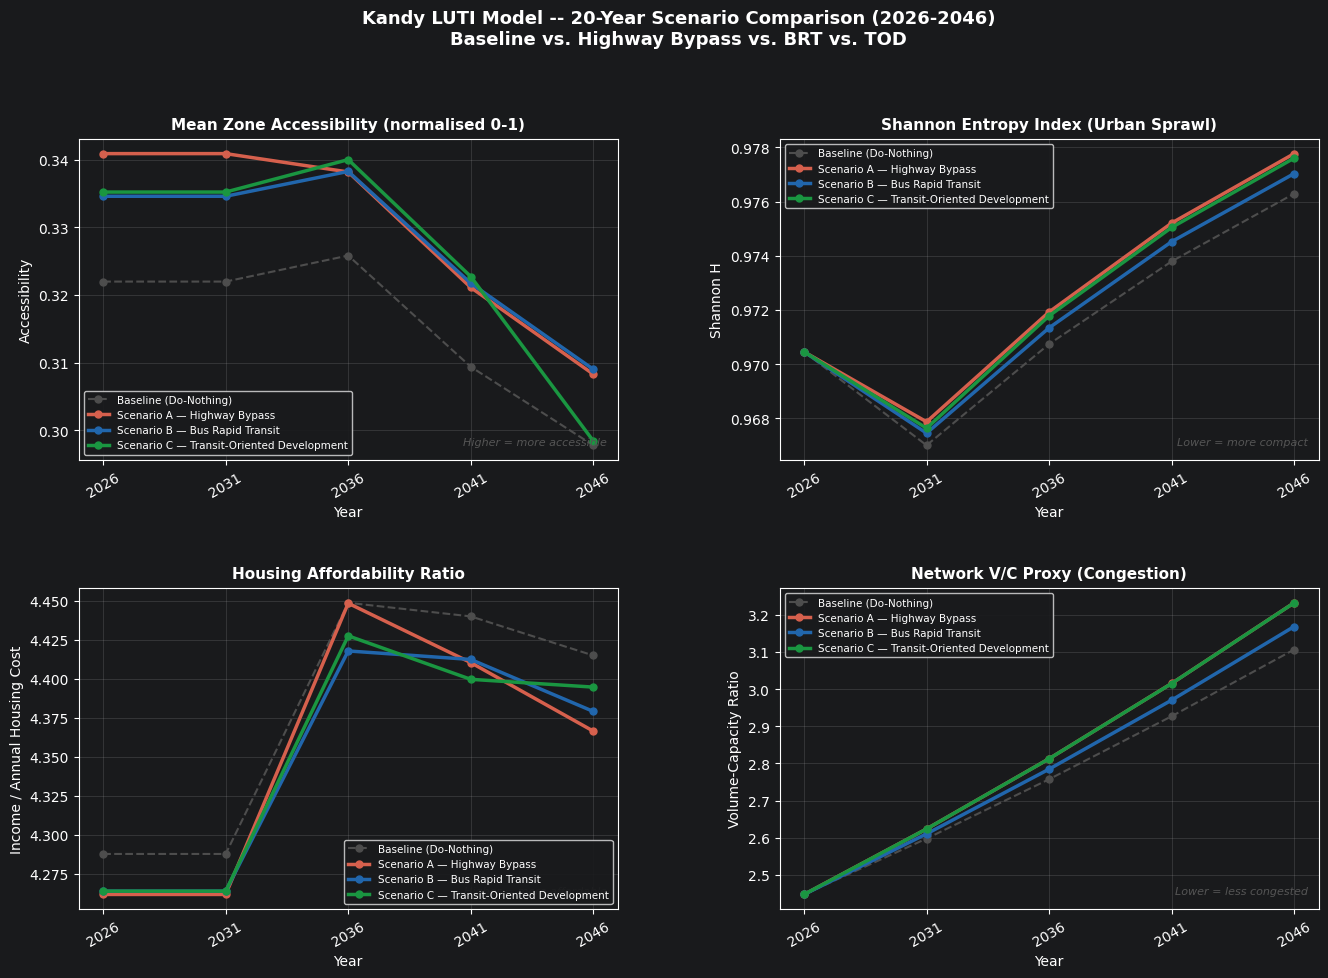

Saved: step12_scenario_comparison.png


In [19]:
# ══════════════════════════════════════════════════════════════
# CELL 18 — Figure 1: Four-panel scenario comparison
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.30)

panels = [
    (gs[0,0], 'mean_accessibility', 'Mean Zone Accessibility (normalised 0-1)',
     'Accessibility',          'Higher = more accessible'),
    (gs[0,1], 'shannon_entropy',    'Shannon Entropy Index (Urban Sprawl)',
     'Shannon H',              'Lower = more compact'),
    (gs[1,0], 'affordability_ratio','Housing Affordability Ratio',
     'Income / Annual Housing Cost','Higher = more affordable'),
    (gs[1,1], 'vc_proxy',           'Network V/C Proxy (Congestion)',
     'Volume-Capacity Ratio',  'Lower = less congested'),
]

for spec, metric, title, ylabel, note in panels:
    ax = fig.add_subplot(spec)
    for scen in SCENARIOS:
        sub = all_metrics[all_metrics['scenario']==scen].sort_values('year')
        c   = SCENARIO_CONFIG[scen]['colour']
        lbl = SCENARIO_CONFIG[scen]['label']
        lw  = 2.5 if scen != 'baseline' else 1.5
        ls  = '-' if scen != 'baseline' else '--'
        ax.plot(sub['year'], sub[metric],
                color=c, lw=lw, ls=ls, marker='o', ms=5, label=lbl)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=7)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.text(0.98, 0.04, note, transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8, color='#555', style='italic')
    ax.set_xticks(TIME_STEPS)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7.5, loc='best', framealpha=0.9)

fig.suptitle(
    'Kandy LUTI Model -- 20-Year Scenario Comparison (2026-2046)\n'
    'Baseline vs. Highway Bypass vs. BRT vs. TOD',
    fontsize=13, fontweight='bold', y=1.01)

out1 = RESULTS_DIR / 'step12_scenario_comparison.png'
plt.savefig(out1, dpi=150, bbox_inches='tight');  plt.show()
print(f'Saved: {out1.name}')


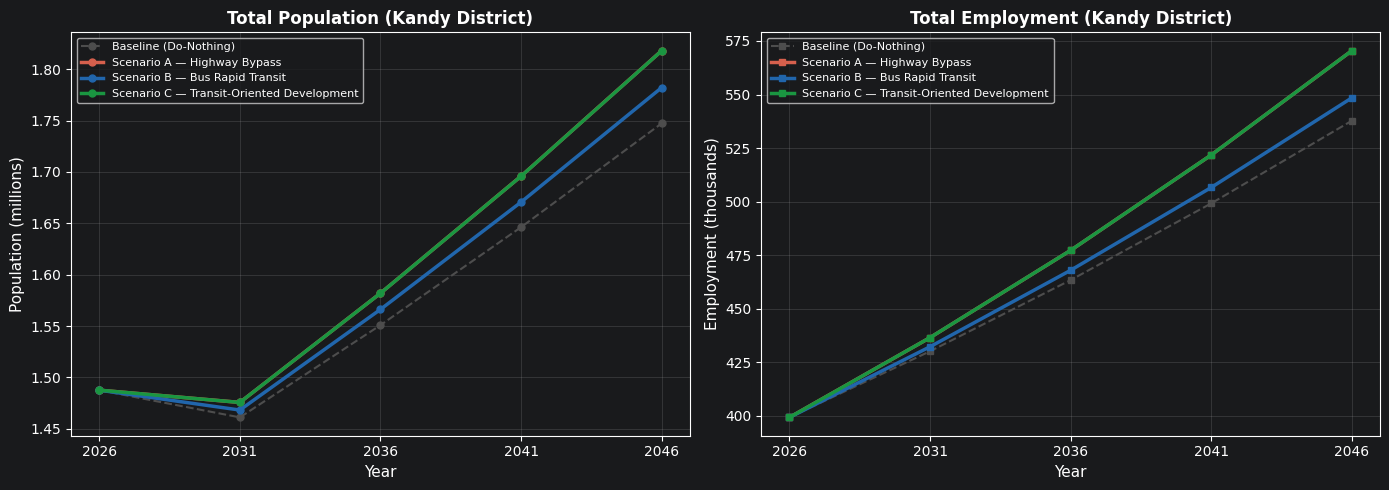

Saved: step12_population_employment.png


In [20]:
# ══════════════════════════════════════════════════════════════
# CELL 19 — Figure 2: Population & employment growth
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label, fmt in [
    (axes[0], 'population',  'Population',         '{:.2f} M'),
    (axes[1], 'employment',  'Employment',          '{:.0f} k'),
]:
    scale = 1e6 if col == 'population' else 1e3
    mk    = 'o' if col == 'population' else 's'
    for scen in SCENARIOS:
        sub = all_metrics[all_metrics['scenario']==scen].sort_values('year')
        ax.plot(sub['year'], sub[col]/scale,
                color=SCENARIO_CONFIG[scen]['colour'],
                lw=2.5 if scen != 'baseline' else 1.5,
                ls='-' if scen != 'baseline' else '--',
                marker=mk, ms=5,
                label=SCENARIO_CONFIG[scen]['label'])
    ax.set_title(f'Total {label} (Kandy District)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel(f'{label} ({"millions" if scale==1e6 else "thousands"})', fontsize=11)
    ax.set_xticks(TIME_STEPS)
    ax.legend(fontsize=8);  ax.grid(alpha=0.25)

plt.tight_layout()
out2 = RESULTS_DIR / 'step12_population_employment.png'
plt.savefig(out2, dpi=150, bbox_inches='tight');  plt.show()
print(f'Saved: {out2.name}')


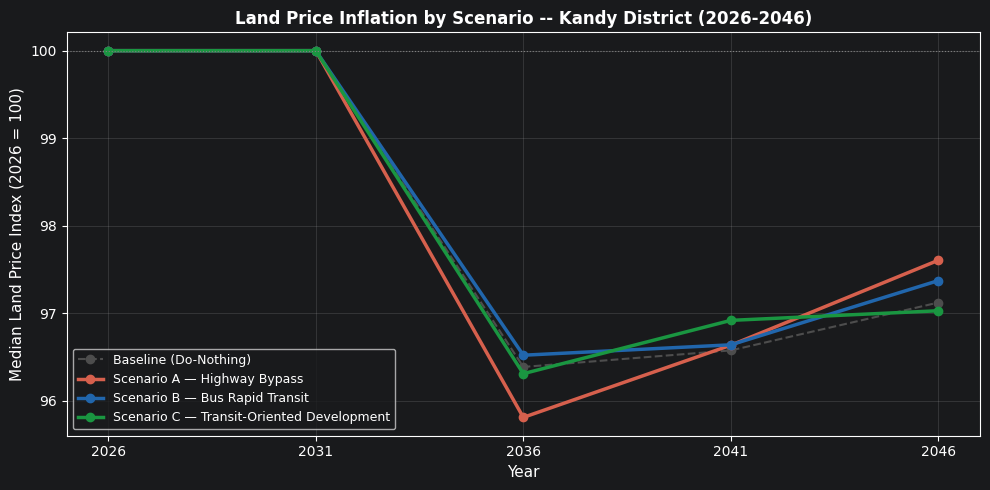

Saved: step12_land_price_index.png


In [21]:
# ══════════════════════════════════════════════════════════════
# CELL 20 — Figure 3: Land price inflation index (2026 = 100)
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))

for scen in SCENARIOS:
    sub  = all_metrics[all_metrics['scenario']==scen].sort_values('year')
    base = sub.loc[sub['year']==2026, 'median_land_price'].values
    if len(base) == 0 or base[0] == 0:
        continue
    idx  = (sub['median_land_price'] / base[0]) * 100
    ax.plot(sub['year'], idx,
            color=SCENARIO_CONFIG[scen]['colour'],
            lw=2.5 if scen != 'baseline' else 1.5,
            ls='-' if scen != 'baseline' else '--',
            marker='o', ms=6,
            label=SCENARIO_CONFIG[scen]['label'])

ax.axhline(100, color='grey', lw=0.8, ls=':')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Median Land Price Index (2026 = 100)', fontsize=11)
ax.set_title('Land Price Inflation by Scenario -- Kandy District (2026-2046)',
             fontsize=12, fontweight='bold')
ax.set_xticks(TIME_STEPS)
ax.legend(fontsize=9);  ax.grid(alpha=0.25)
plt.tight_layout()
out3 = RESULTS_DIR / 'step12_land_price_index.png'
plt.savefig(out3, dpi=150, bbox_inches='tight');  plt.show()
print(f'Saved: {out3.name}')


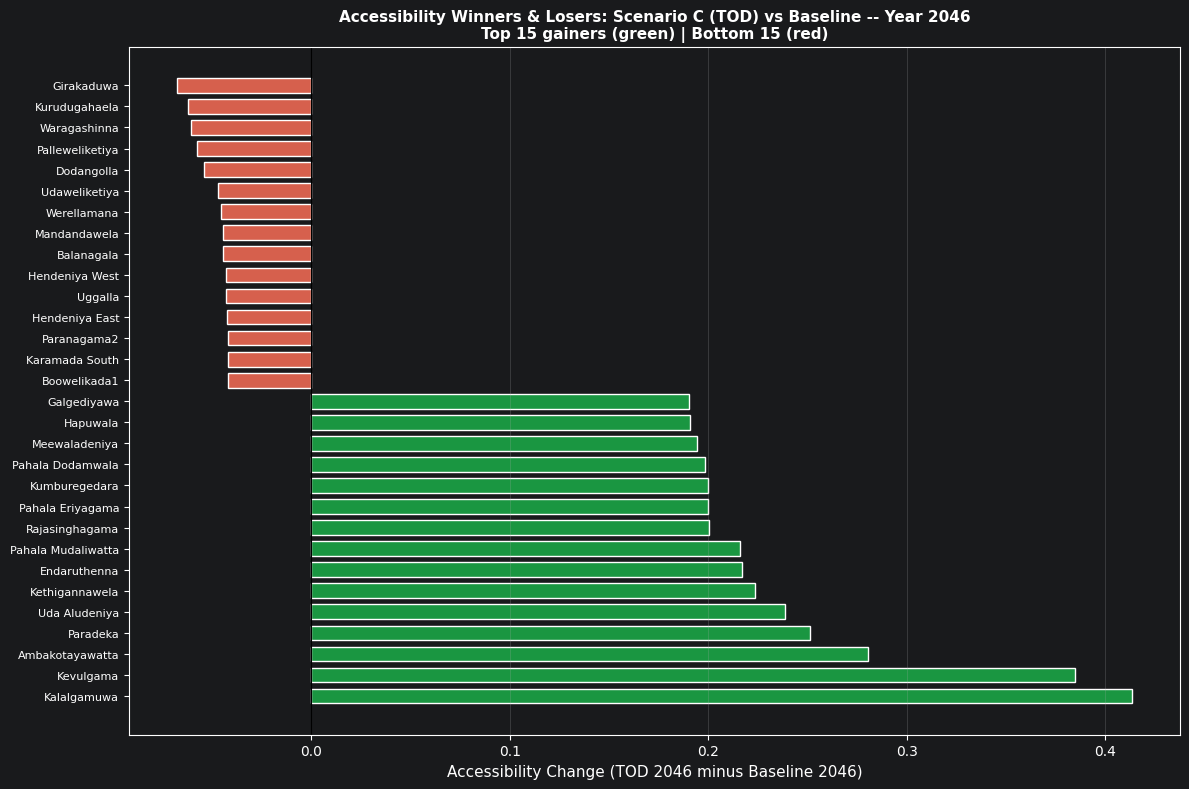

Saved: step12_accessibility_delta_tod_vs_baseline.png


In [22]:
# ══════════════════════════════════════════════════════════════
# CELL 21 — Figure 4: Accessibility winners & losers
#           TOD 2046 vs Baseline 2046 (top/bottom 15 zones)
# ══════════════════════════════════════════════════════════════
z_base = ALL_RESULTS['baseline'][2046]['zones'].copy()
z_tod  = ALL_RESULTS['scenario_c'][2046]['zones'].copy()

delta = (z_tod['accessibility'] - z_base['accessibility']).sort_values(ascending=False)
top15 = delta.head(15)
bot15 = delta.tail(15)
combined = pd.concat([top15, bot15])

gn_col = 'GN_Name' if 'GN_Name' in census.columns else None
labels = [
    (census.loc[i, gn_col][:22] if gn_col and i in census.index else str(i))
    for i in combined.index
]

fig, ax = plt.subplots(figsize=(12, 8))
colours = ['#1a9641' if v >= 0 else '#d6604d' for v in combined.values]
ax.barh(range(len(combined)), combined.values, color=colours,
        edgecolor='white', height=0.7)
ax.set_yticks(range(len(combined)))
ax.set_yticklabels(labels, fontsize=8)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Accessibility Change (TOD 2046 minus Baseline 2046)', fontsize=11)
ax.set_title(
    'Accessibility Winners & Losers: Scenario C (TOD) vs Baseline -- Year 2046\n'
    'Top 15 gainers (green) | Bottom 15 (red)',
    fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
out4 = RESULTS_DIR / 'step12_accessibility_delta_tod_vs_baseline.png'
plt.savefig(out4, dpi=150, bbox_inches='tight');  plt.show()
print(f'Saved: {out4.name}')


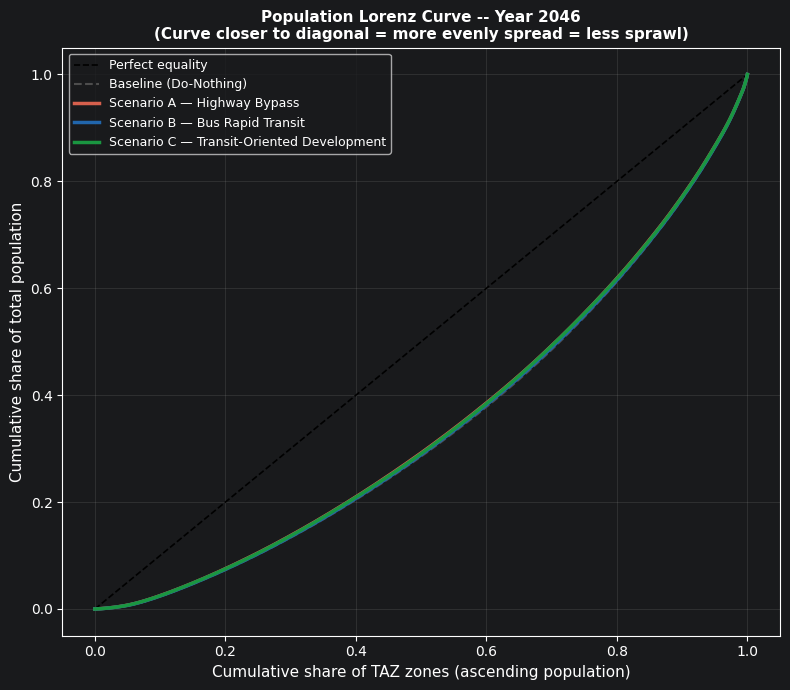

Saved: step12_lorenz_population_2046.png


In [23]:
# ══════════════════════════════════════════════════════════════
# CELL 22 — Figure 5: Population Lorenz curve (spatial equality)
# ══════════════════════════════════════════════════════════════

def lorenz_curve(values: np.ndarray):
    sv  = np.sort(values.clip(min=0))
    n   = len(sv)
    cx  = np.linspace(0, 1, n + 1)
    cy  = np.concatenate([[0], np.cumsum(sv) / sv.sum()])
    return cx, cy

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect equality')

for scen in SCENARIOS:
    z   = ALL_RESULTS[scen][2046]['zones']
    x, y = lorenz_curve(z['population'].fillna(0).values)
    ax.plot(x, y,
            color=SCENARIO_CONFIG[scen]['colour'],
            lw=2.5 if scen != 'baseline' else 1.5,
            ls='-' if scen != 'baseline' else '--',
            label=SCENARIO_CONFIG[scen]['label'])

ax.set_xlabel('Cumulative share of TAZ zones (ascending population)', fontsize=11)
ax.set_ylabel('Cumulative share of total population', fontsize=11)
ax.set_title(
    'Population Lorenz Curve -- Year 2046\n'
    '(Curve closer to diagonal = more evenly spread = less sprawl)',
    fontsize=11, fontweight='bold')
ax.legend(fontsize=9);  ax.grid(alpha=0.2)
plt.tight_layout()
out5 = RESULTS_DIR / 'step12_lorenz_population_2046.png'
plt.savefig(out5, dpi=150, bbox_inches='tight');  plt.show()
print(f'Saved: {out5.name}')


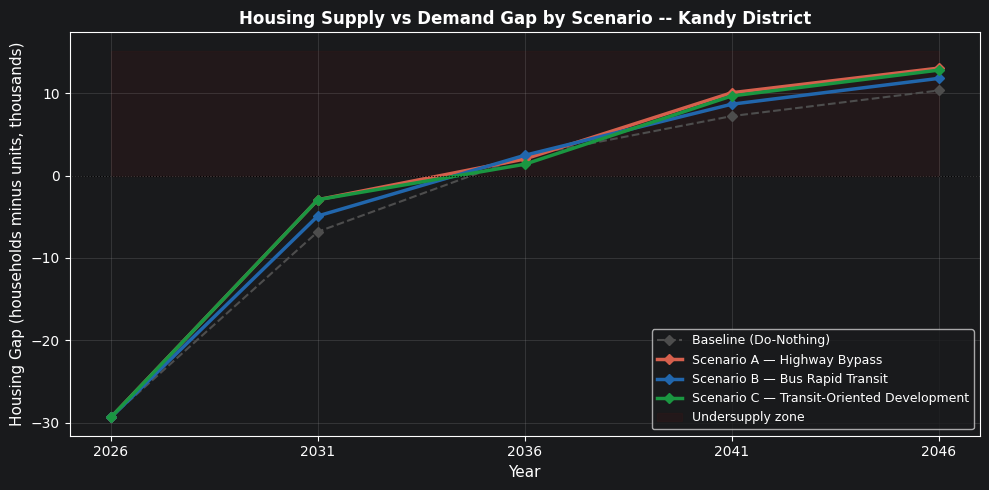

Saved: step12_housing_supply_gap.png


In [24]:
# ══════════════════════════════════════════════════════════════
# CELL 23 — Figure 6: Housing supply vs demand gap over time
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))

for scen in SCENARIOS:
    sub   = all_metrics[all_metrics['scenario']==scen].sort_values('year')
    gap   = sub['households'] - sub['housing_units']   # positive = undersupply
    ax.plot(sub['year'], gap / 1e3,
            color=SCENARIO_CONFIG[scen]['colour'],
            lw=2.5 if scen != 'baseline' else 1.5,
            ls='-' if scen != 'baseline' else '--',
            marker='D', ms=5,
            label=SCENARIO_CONFIG[scen]['label'])

ax.axhline(0, color='black', lw=0.8, ls=':')
ax.fill_between([2026, 2046], 0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 10,
                alpha=0.04, color='red', label='Undersupply zone')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Housing Gap (households minus units, thousands)', fontsize=11)
ax.set_title('Housing Supply vs Demand Gap by Scenario -- Kandy District',
             fontsize=12, fontweight='bold')
ax.set_xticks(TIME_STEPS)
ax.legend(fontsize=9);  ax.grid(alpha=0.25)
plt.tight_layout()
out6 = RESULTS_DIR / 'step12_housing_supply_gap.png'
plt.savefig(out6, dpi=150, bbox_inches='tight');  plt.show()
print(f'Saved: {out6.name}')


In [25]:
# ══════════════════════════════════════════════════════════════
# CELL 24 — Key findings summary & cross-scenario delta table
# ══════════════════════════════════════════════════════════════
SEP = chr(9552) * 70
print(SEP)
print('  STEP 12 KEY FINDINGS  --  Year 2046 vs Baseline')
print(SEP)

base46 = all_metrics[
    (all_metrics['scenario']=='baseline') &
    (all_metrics['year']==2046)
].iloc[0]

delta_rows = []
for scen in ['scenario_a', 'scenario_b', 'scenario_c']:
    row = all_metrics[
        (all_metrics['scenario']==scen) &
        (all_metrics['year']==2046)
    ].iloc[0]
    lbl   = SCENARIO_CONFIG[scen]['label']
    d_acc = row['mean_accessibility'] - base46['mean_accessibility']
    d_ent = row['shannon_entropy']    - base46['shannon_entropy']
    d_aff = (row['affordability_ratio'] - base46['affordability_ratio']
             if pd.notna(row['affordability_ratio']) else float('nan'))
    d_vc  = row['vc_proxy']           - base46['vc_proxy']
    d_pop = (row['population']        - base46['population'])
    d_emp = (row['employment']        - base46['employment'])
    print(f'\n  {lbl}')
    print(f'    Population change vs baseline   : {d_pop:+,.0f}')
    print(f'    Employment change vs baseline   : {d_emp:+,.0f}')
    print(f'    Accessibility delta             : {d_acc:+.4f}')
    print(f'    Sprawl (Shannon H) delta        : {d_ent:+.4f}  '
          f'({"more compact" if d_ent < 0 else "more dispersed"})')
    print(f'    Affordability ratio delta       : {d_aff:+.3f}')
    print(f'    V/C proxy delta                 : {d_vc:+.4f}  '
          f'({"less congested" if d_vc < 0 else "more congested"})')
    delta_rows.append({'Scenario':lbl,
                        'Pop delta':d_pop, 'Emp delta':d_emp,
                        'Acc delta':d_acc,
                        'Sprawl delta':d_ent,
                        'Affordability delta':d_aff,
                        'V/C delta':d_vc})

delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(RESULTS_DIR / 'scenario_deltas_vs_baseline_2046.csv', index=False)
print(f'\n{SEP}')
print('  Delta table saved: results/scenario_deltas_vs_baseline_2046.csv')
print(SEP)


══════════════════════════════════════════════════════════════════════
  STEP 12 KEY FINDINGS  --  Year 2046 vs Baseline
══════════════════════════════════════════════════════════════════════

  Scenario A — Highway Bypass
    Population change vs baseline   : +70,737
    Employment change vs baseline   : +32,694
    Accessibility delta             : +0.0105
    Sprawl (Shannon H) delta        : +0.0015  (more dispersed)
    Affordability ratio delta       : -0.048
    V/C proxy delta                 : +0.1258  (more congested)

  Scenario B — Bus Rapid Transit
    Population change vs baseline   : +34,807
    Employment change vs baseline   : +10,686
    Accessibility delta             : +0.0112
    Sprawl (Shannon H) delta        : +0.0007  (more dispersed)
    Affordability ratio delta       : -0.036
    V/C proxy delta                 : +0.0619  (more congested)

  Scenario C — Transit-Oriented Development
    Population change vs baseline   : +70,657
    Employment change vs basel

In [26]:
# ══════════════════════════════════════════════════════════════
# CELL 25 — File manifest: all Step 12 outputs
# ══════════════════════════════════════════════════════════════
import os
print('Step 12 output files:')
print()

for folder in [RESULTS_DIR, LU_DIR]:
    files = sorted(folder.rglob('*'))
    if files:
        print(f'  {folder.relative_to(BASE_DIR)}/')
        for f in files:
            if f.is_file():
                kb = f.stat().st_size / 1024
                rel = str(f.relative_to(folder))
                print(f'    {rel:52s}  {kb:7.1f} KB')
        print()


Step 12 output files:

  results/
    all_scenarios_timeseries.csv                              3.0 KB
    baseline\step12_accessibility_baseline_2026.png          75.5 KB
    scenario_comparison_2046.csv                              0.7 KB
    scenario_deltas_vs_baseline_2046.csv                      0.5 KB
    step12_accessibility_delta_tod_vs_baseline.png          122.9 KB
    step12_housing_supply_gap.png                           101.5 KB
    step12_land_price_index.png                             106.0 KB
    step12_lorenz_population_2046.png                       116.1 KB
    step12_population_employment.png                        145.5 KB
    step12_scenario_comparison.png                          351.9 KB

  land_use/
    baseline\metrics_timeseries.csv                           0.9 KB
    baseline\zones_2026.csv                                 176.3 KB
    baseline\zones_2031.csv                                 192.2 KB
    baseline\zones_2036.csv                             

---
## What Step 12 produced

| Output | Description |
|---|---|
| `results/scenario_comparison_2046.csv` | Year-2046 cross-scenario table (all metrics) |
| `results/all_scenarios_timeseries.csv` | Year-by-year metrics, all scenarios |
| `results/scenario_deltas_vs_baseline_2046.csv` | Change vs baseline at Year 2046 |
| `results/step12_scenario_comparison.png` | 4-panel chart: accessibility, sprawl, affordability, V/C |
| `results/step12_population_employment.png` | Population & employment growth trajectories |
| `results/step12_land_price_index.png` | Land price inflation (2026 = 100) |
| `results/step12_accessibility_delta_tod_vs_baseline.png` | TOD winners & losers |
| `results/step12_lorenz_population_2046.png` | Population Lorenz curve |
| `results/step12_housing_supply_gap.png` | Housing demand–supply gap |
| `land_use/<scenario>/zones_<year>.csv` | Zone-level snapshots (4 scenarios × 5 years = 20 files) |
| `land_use/<scenario>/metrics_timeseries.csv` | Per-scenario metrics time series (4 files) |

---

## Methodological notes

**Accessibility decay (β = 0.08)** is the calibrated value from Step 10. It reflects
Kandy's hilly topography, where generalised-cost sensitivity is slightly lower than
flat-city literature values (β = 0.10–0.15). A sensitivity analysis varying β across
[0.05, 0.08, 0.12] is recommended before finalising results.

**Scenario skim modifiers** (18 % bypass, 10 % BRT) are derived from comparable South Asian
evaluations: JICA Greater Kandy Urban Plan 2018 (bypass) and World Bank P172342
BRT appraisal (PT). These are conservative estimates; OpenTripPlanner PT skims
(Step 9, OTP module) will refine BRT generalised costs in Scenarios B and C.

**Land use model coefficients** are seeded from Kandy property data and Census 2024.
They will be re-estimated during Step 16 (historical validation) against observed
2005–2020 LULC change to confirm their predictive accuracy.

**UrbanSim compatibility:** When `pip install urbansim orca` is available, the built-in
MNL implementations can be replaced with `MNLLocationChoiceModel` from the
`urbansim.models` module. All DataFrames are already in the expected format.

---

## Next step

**Step 13 — LULC Classification on Historical Imagery**\
Classify Sentinel-2 / Landsat imagery (2005, 2010, 2015, 2020) to produce
ground-truth urban extent maps for historical validation in Step 16.
